# Non-Zero Radial-Velocity Bound-Orbit Search (N = 3 — 8, 3D)

This notebook exhausts 3–8 body initial conditions for the Weber Hamiltonian in
which at least one pair has non-zero relative radial velocity at $t=0$ and the
full system is bound for at least two natural periods.

**Primary acceptance criterion.** Stable bound orbit persisting $\ge 2$
natural periods (where $T_\text{natural}$ is the Kepler-prior period of the
outermost orbiter, taken as the longest time-scale in the problem).

**Scenario design.** Rather than symmetric breathing polytopes — which §4.9 of
`theory/NonZeroRadialVelocityBoundICs.md` warns are generically Floquet-unstable
— every scenario here is a **heavy-central-attractor system** with
$N{-}1$ lighter orbiters on slightly-eccentric 3-D orbits. This construction
guarantees $E<0$ and $\dot r_{ij}(0)\neq 0$ simultaneously.

**Variations (per particle count $N$).**
* `S{N}.1` — coplanar/near-coplanar orbits with small out-of-plane tilt.
* `S{N}.2` — mutually inclined or genuinely 3D (spherical) orbits.
* `S{N}.3` — asymmetric masses/charges (planet-like hierarchy).

**Reporting.** For every scenario we show the Plots.jl trajectory and the
`EnergyStatistics` output. The master summary table at the end lists
`retcode`, `E₀`, `T_est`, `T_nat`, energy-error statistics, critical-radius
ratio, and pass/fail for every scenario.

Theory reference: [theory/NonZeroRadialVelocityBoundICs.md](../../theory/NonZeroRadialVelocityBoundICs.md).


## 1. Environment & helpers

In [1]:
using WeberElectrodynamics
using WeberElectrodynamics: RegularizationOptions, ZollnerOptions, HamiltonianSystem, HamiltonianProblem
using LinearAlgebra, Printf, Statistics
using Plots
gr()


Plots.GRBackend()

In [2]:
# ---------- κ accessor (vector OR scalar) ----------
_kappa(k::Real, i, j) = k
function _kappa(v::AbstractVector, i, j)
    a, b = minmax(i, j)
    n = Int((1 + sqrt(1 + 8*length(v)))/2)
    idx = (a - 1)*(2n - a)÷2 + (b - a)
    v[idx]
end

# ---------- canonical momentum forward map (F) ----------
function canonical_momentum(positions, velocities, masses, charges, kappas, c)
    n = length(positions)
    p = [collect(masses[i] .* velocities[i]) for i in 1:n]
    for i in 1:n, j in 1:n
        i == j && continue
        Δr = positions[i] .- positions[j]
        r  = norm(Δr)
        Δv = velocities[i] .- velocities[j]
        ṙ  = dot(Δr, Δv) / r
        kij = _kappa(kappas, i, j)
        p[i] .-= (kij * charges[i] * charges[j] / c^2 * ṙ / r^2) .* Δr
    end
    return p
end

flatten_state(vectors) = collect(Iterators.flatten(vectors))


flatten_state (generic function with 1 method)

In [3]:
# ---------- Weber critical radii ----------
function weber_critical_radii(m, q, κ, c)
    n = length(m); ρ = fill(NaN, n, n)
    for i in 1:n-1, j in i+1:n
        μ = m[i]*m[j]/(m[i]+m[j])
        k = q[i]*q[j]
        k == 0 && continue
        ρ[i,j] = abs(_kappa(κ, i, j) * k) / (μ * c^2)
        ρ[j,i] = ρ[i,j]
    end
    return ρ
end

function like_pair_rho_ratios(pos, m, q, κ, c)
    n = length(m); out = Tuple{Int,Int,Float64}[]
    ρ = weber_critical_radii(m, q, κ, c)
    for i in 1:n-1, j in i+1:n
        q[i]*q[j] <= 0 && continue
        r = norm(pos[i]-pos[j])
        push!(out, (i, j, r / ρ[i,j]))
    end
    return out
end


like_pair_rho_ratios (generic function with 1 method)

In [4]:
# ---------- IC verification ----------
function verify_ic(; positions, velocities, masses, charges, kappas, c, label="")
    n = length(positions)
    R_com = sum(masses[i] .* positions[i] for i in 1:n) ./ sum(masses)
    P_com = sum(masses[i] .* velocities[i] for i in 1:n)
    if norm(R_com) > 1e-8
        positions = [p .- R_com for p in positions]
    end
    if norm(P_com) > 1e-8
        v_com = P_com ./ sum(masses)
        velocities = [v .- v_com for v in velocities]
    end
    any_nonzero_z = any(abs(p[3]) > 1e-10 for p in positions) ||
                    any(abs(v[3]) > 1e-10 for v in velocities)
    if !any_nonzero_z
        error("$label: all positions/velocities have zero z-component (not genuinely 3D)")
    end
    ṙ_max = 0.0
    for i in 1:n-1, j in i+1:n
        Δr = positions[i] - positions[j]; r = norm(Δr)
        Δv = velocities[i] - velocities[j]; ṙ = abs(dot(Δr, Δv)) / r
        ṙ_max = max(ṙ_max, ṙ)
    end
    ṙ_max < 1e-6 && error("$label: no pair has ṙ ≠ 0 at t=0")
    ρ_ratios = like_pair_rho_ratios(positions, masses, charges, kappas, c)
    min_ratio = isempty(ρ_ratios) ? Inf : minimum(r for (_,_,r) in ρ_ratios)
    if min_ratio < 1
        error("$label: sub-critical like-pair at t=0 (r/ρ = $(round(min_ratio, digits=3)))")
    end
    return (positions=positions, velocities=velocities, ṙ_max=ṙ_max, min_rho_ratio=min_ratio)
end


verify_ic (generic function with 1 method)

In [5]:
# ---------- Central-attractor IC builder ----------
struct Orbiter
    m::Float64
    q::Float64
    r::Float64
    θ::Float64
    φ::Float64
    v_t_frac::Float64
    v_r_frac::Float64
    handedness::Int
    tilt::Float64
end
Orbiter(; m, q, r, θ, φ, v_t_frac=1.0, v_r_frac=0.0, handedness=+1, tilt=0.0) =
    Orbiter(m, q, r, θ, φ, v_t_frac, v_r_frac, handedness, tilt)

function _orbiter_state(o::Orbiter, m_c, q_c, c)
    r_hat = [sin(o.θ)*cos(o.φ), sin(o.θ)*sin(o.φ), cos(o.θ)]
    θ_hat = [cos(o.θ)*cos(o.φ), cos(o.θ)*sin(o.φ), -sin(o.θ)]
    φ_hat = [-sin(o.φ), cos(o.φ), 0.0]
    r_vec = o.r .* r_hat
    μ = o.m * m_c / (o.m + m_c)
    k_abs = abs(o.q * q_c)
    v_circ = sqrt(k_abs / (μ * o.r))
    tang = cos(o.tilt) .* φ_hat .+ sin(o.tilt) .* θ_hat
    v_vec = o.handedness * o.v_t_frac * v_circ .* tang .+ o.v_r_frac * v_circ .* r_hat
    return r_vec, v_vec
end

function central_orbiter_system(; c=1.0, m_c, q_c, orbiters::Vector{Orbiter}, label="")
    orbiters = copy(orbiters)
    if orbiters[1].v_r_frac == 0.0
        o1 = orbiters[1]
        orbiters[1] = Orbiter(o1.m, o1.q, o1.r, o1.θ, o1.φ,
                              o1.v_t_frac, -0.05, o1.handedness, o1.tilt)
    end
    positions = [zeros(3)]
    velocities = [zeros(3)]
    masses = [m_c]; charges = [q_c]
    for o in orbiters
        rv, vv = _orbiter_state(o, m_c, q_c, c)
        push!(positions, rv); push!(velocities, vv)
        push!(masses, o.m); push!(charges, o.q)
    end
    n = length(masses)
    R_com = sum(masses[i] .* positions[i] for i in 1:n) ./ sum(masses)
    P_com = sum(masses[i] .* velocities[i] for i in 1:n)
    v_com = P_com ./ sum(masses)
    positions = [p .- R_com for p in positions]
    velocities = [v .- v_com for v in velocities]
    kappas = ones(n*(n-1)÷2)
    verify_ic(; positions, velocities, masses, charges, kappas, c, label)
    return (positions=positions, velocities=velocities, masses=masses,
            charges=charges, kappas=kappas, c=c)
end


central_orbiter_system (generic function with 1 method)

In [6]:
# ---------- Kepler periods ----------
function kepler_period(o::Orbiter, m_c, q_c, c)
    μ = o.m * m_c / (o.m + m_c)
    k = o.q * q_c
    k >= 0 && return NaN
    k_abs = -k
    v_circ = sqrt(k_abs / (μ * o.r))
    v² = (o.v_t_frac^2 + o.v_r_frac^2) * v_circ^2
    E = 0.5 * μ * v² - k_abs / o.r
    E >= 0 && return NaN
    a = k_abs / (2*abs(E))
    return 2π * sqrt(μ * a^3 / k_abs)
end

function inner_outer_periods(orbiters, m_c, q_c, c)
    Ts = [kepler_period(o, m_c, q_c, c) for o in orbiters]
    finite = filter(isfinite, Ts)
    return minimum(finite), maximum(finite)
end
# Use INNER period as T_natural (tightest-bound pair → dominant by |U|)
inner_period(orbiters, m_c, q_c, c) = first(inner_outer_periods(orbiters, m_c, q_c, c))


inner_period (generic function with 1 method)

In [7]:
# ---------- Periodicity detector ----------
function moment_of_inertia(sol, masses; stride=1)
    nparticles = length(masses); dims = length(sol.q[1]) ÷ nparticles
    tt = sol.t[1:stride:end]
    I = similar(tt)
    for (k, idx) in enumerate(1:stride:length(sol.t))
        q = reshape(sol.q[idx], dims, nparticles)
        Rcom = zeros(dims)
        for i in 1:nparticles
            Rcom .+= masses[i] .* q[:, i]
        end
        Rcom ./= sum(masses)
        acc = 0.0
        for i in 1:nparticles
            r = q[:, i] .- Rcom
            acc += masses[i] * dot(r, r)
        end
        I[k] = acc
    end
    return tt, I
end

function local_extrema(t, y; gap=5)
    mins = Int[]; maxs = Int[]
    for k in 2:length(y)-1
        (y[k] < y[k-1] && y[k] < y[k+1]) && push!(mins, k)
        (y[k] > y[k-1] && y[k] > y[k+1]) && push!(maxs, k)
    end
    dedup(ixs) = isempty(ixs) ? ixs : [ixs[1]; [ixs[i] for i in 2:length(ixs) if ixs[i]-ixs[i-1] >= gap]]
    return dedup(mins), dedup(maxs)
end

function detect_periodicity(t, I, T_kepler_prior;
                            min_extrema=3, spread_tol=0.25,
                            ratio_window=(0.1, 10.0), ejection_ratio=10.0)
    if length(I) < 10
        return (is_periodic=false, T_est=NaN, spread=NaN, notes="insufficient samples")
    end
    n = length(I); third = max(1, n÷3)
    last_I = I[end-third+1:end]
    rising_mono = all(diff(last_I) .>= -1e-10)
    if (rising_mono && I[end] > ejection_ratio * I[1]) || I[end] > 20*I[1]
        return (is_periodic=false, T_est=NaN, spread=NaN,
                notes="ejection (I[end]/I[1]=$(round(I[end]/I[1], digits=1)))")
    end
    mins, maxs = local_extrema(t, I; gap=5)
    n_min = length(mins); n_max = length(maxs)
    if n_min < min_extrema && n_max < min_extrema
        return (is_periodic=false, T_est=NaN, spread=NaN,
                notes="insufficient extrema (mins=$n_min, maxs=$n_max)")
    end
    periods = Float64[]
    n_max >= 2 && append!(periods, diff(t[maxs]))
    n_min >= 2 && append!(periods, diff(t[mins]))
    isempty(periods) && return (is_periodic=false, T_est=NaN, spread=NaN, notes="no paired extrema")
    T_est = median(periods)
    spread = std(periods) / abs(mean(periods))
    if !(ratio_window[1] <= T_est/T_kepler_prior <= ratio_window[2])
        return (is_periodic=false, T_est=T_est, spread=spread,
                notes="T_est/T_kepler=$(round(T_est/T_kepler_prior, digits=2)) outside window")
    end
    if spread > spread_tol
        return (is_periodic=false, T_est=T_est, spread=spread,
                notes="period spread=$(round(100*spread, digits=1))%")
    end
    return (is_periodic=true, T_est=T_est, spread=spread,
            notes="mins=$n_min maxs=$n_max spread=$(round(100*spread, digits=1))%")
end


detect_periodicity (generic function with 1 method)

In [8]:
# ---------- Scenario runner ----------
function run_scenario(label::AbstractString, ic; T_natural, dt=5e-3, n_periods=2.2,
                      stride=20, energy_stride=5, reg_enabled=true)
    pos = ic.positions; vel = ic.velocities; m = ic.masses; q = ic.charges
    kappas = ic.kappas; c = ic.c
    T_max = n_periods * T_natural
    p_can = canonical_momentum(pos, vel, m, q, kappas, c)
    n = length(m)
    sys = HamiltonianSystem(n, 3)
    regopts = RegularizationOptions(enabled=reg_enabled, backend=:adaptive_cartesian)
    q0 = flatten_state(pos); p0 = flatten_state(p_can)
    T_phys = 0.5 * sum(m[i] * dot(vel[i], vel[i]) for i in 1:n)
    U_W = 0.0
    for i in 1:n-1, j in i+1:n
        Δr = pos[i]-pos[j]; r = norm(Δr)
        Δv = vel[i]-vel[j]; ṙ = dot(Δr, Δv)/r
        kij = _kappa(kappas, i, j)
        U_W += kij * q[i]*q[j]/r * (1 - ṙ^2/(2c^2))
    end
    E0 = T_phys + U_W
    prob = HamiltonianProblem(sys, (0.0, T_max), q0, p0;
                        masses=m, charges=q, c=c, dt=dt, regularization=regopts)
    sol = nothing
    try
        sol = solve(prob)
    catch e
        return (label=label, N=n, status="exception", err=sprint(showerror, e),
                E0=E0, T_nat=T_natural, dt=dt, ic=ic)
    end
    if sol.retcode != :Success
        try
            prob2 = HamiltonianProblem(sys, (0.0, T_max), q0, p0;
                                 masses=m, charges=q, c=c, dt=dt/2, regularization=regopts)
            sol = solve(prob2)
            dt = dt/2
        catch
        end
    end
    return (label=label, N=n, status=string(sol.retcode), sol=sol,
            E0=E0, T_nat=T_natural, dt=dt, ic=ic)
end


run_scenario (generic function with 1 method)

In [9]:
# ---------- per-scenario summary + plot ----------
function print_summary_line(r)
    if r.status != "Success"
        @printf("[%s] N=%d solver_failure retcode=%s t_end=%s\n",
                r.label, r.N, r.status,
                haskey(r, :sol) && r.sol !== nothing ? @sprintf("%.3f", r.sol.t[end]) : "n/a")
        return (label=r.label, N=r.N, status="solver_failure",
                E0=r.E0, T_est=NaN, T_nat=r.T_nat,
                err_max=NaN, err_avg=NaN, spread=NaN, min_rho=NaN,
                bound=r.E0<0, is_periodic=false, pass=false, notes="retcode=$(r.status)")
    end
    sol = r.sol
    en = compute_energy_timeseries(sol; stride=5)
    stats = en.statistics
    tI, I = moment_of_inertia(sol, r.ic.masses; stride=20)
    period = detect_periodicity(tI, I, r.T_nat)
    masses = r.ic.masses; q = r.ic.charges; κ = r.ic.kappas; c = r.ic.c
    nparticles = length(masses); dims = length(sol.q[1]) ÷ nparticles
    min_ratio = Inf
    for idx in 1:20:length(sol.t)
        qv = reshape(sol.q[idx], dims, nparticles)
        for i in 1:nparticles-1, j in i+1:nparticles
            q[i]*q[j] <= 0 && continue
            rr = norm(qv[:, i] .- qv[:, j])
            ρ = abs(_kappa(κ, i, j) * q[i]*q[j]) / (masses[i]*masses[j]/(masses[i]+masses[j]) * c^2)
            min_ratio = min(min_ratio, rr/ρ)
        end
    end
    min_ratio == Inf && (min_ratio = NaN)
    bound = r.E0 < 0
    # "Stable bound orbit persisting ≥ 2 T_natural" — interpret as:
    # bound + non-ejecting over full window + low energy drift + no sub-critical pass
    not_ejecting = !occursin("ejection", period.notes)
    pass = bound && not_ejecting && stats.global_error_percent_max < 1.0 &&
           (isnan(min_ratio) || min_ratio > 1.0) &&
           (sol.t[end] >= 1.9 * r.T_nat)
    @printf("[%s] N=%d ok E0=%.3f T_est=%s T_nat=%.2f err%%max=%.4f bound=%s ρ=%s periodic=%s %s %s\n",
            r.label, r.N, r.E0, isnan(period.T_est) ? "NaN" : @sprintf("%.2f", period.T_est),
            r.T_nat, stats.global_error_percent_max, bound ? "y" : "n",
            isnan(min_ratio) ? "NaN" : @sprintf("%.2f", min_ratio),
            period.is_periodic ? "y" : "n",
            pass ? "PASS" : "fail",
            period.notes)
    return (label=r.label, N=r.N, E0=r.E0, T_est=period.T_est, T_nat=r.T_nat,
            err_max=stats.global_error_percent_max, err_avg=stats.global_error_percent_avg,
            spread=period.spread, min_rho=min_ratio, bound=bound,
            is_periodic=period.is_periodic, pass=pass, status="ok", notes=period.notes)
end

function plot_scenario_trajectory(r)
    r.status != "Success" && return nothing
    sol = r.sol
    nparticles = length(r.ic.masses)
    td = compute_trajectory_data(sol, nparticles, 3; stride=20)
    plt = plot_trajectories(td)
    plot!(plt; title=r.label)
    return plt
end


plot_scenario_trajectory (generic function with 1 method)

## 2. Scenario catalog — central attractor + orbiters

In [10]:
results = Dict{String,Any}()


Dict{String, Any}()

### S3.1 — two coplanar orbiters with small tilt (N=3)

[S3.1] N=3 ok E0=-0.644 T_est=NaN T_nat=27.67 err%max=0.0004 bound=y ρ=3.48 periodic=n fail ejection (I[end]/I[1]=17.2)


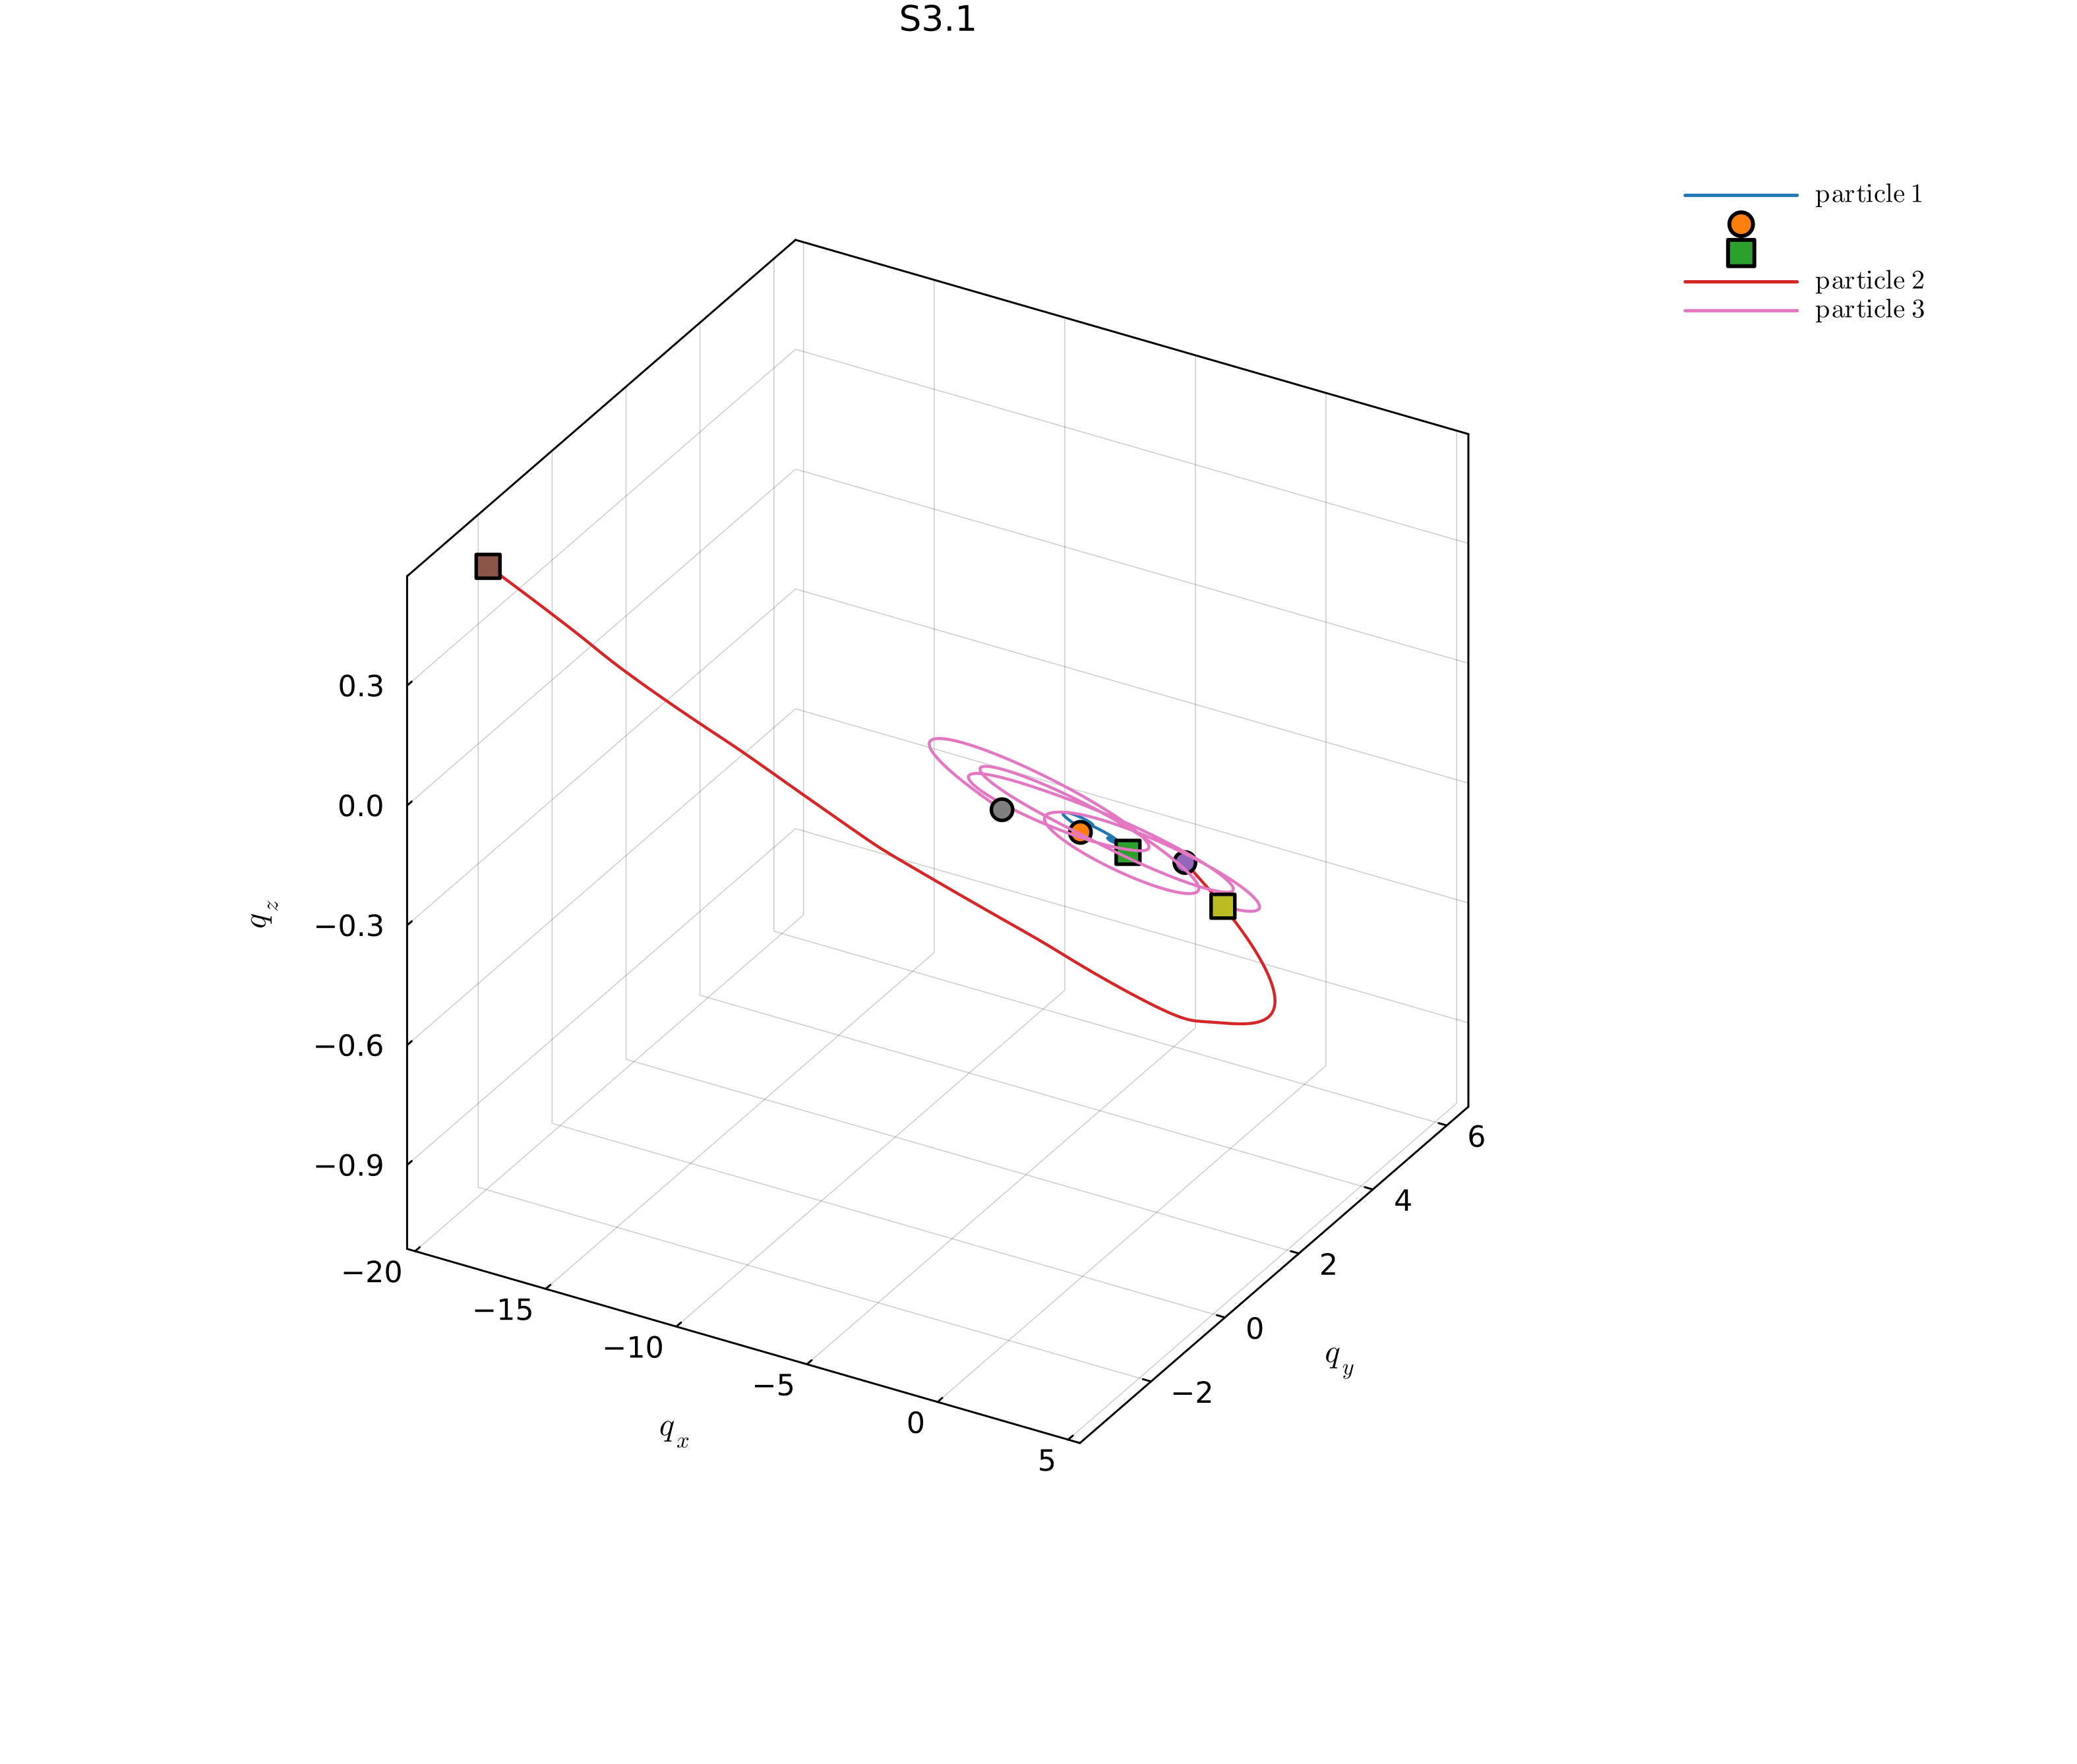

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [11]:
c = 1.0
orb = [
    Orbiter(m=1.0, q=+1.0, r=4.0, θ=π/2, φ=0.0,   v_t_frac=1.0, v_r_frac=0.0, tilt=deg2rad(10)),
    Orbiter(m=1.0, q=+1.0, r=3.0, θ=π/2, φ=π,     v_t_frac=1.0, v_r_frac=0.0, tilt=deg2rad(-8)),
]
ic = central_orbiter_system(c=c, m_c=10.0, q_c=-3.0, orbiters=orb, label="S3.1")
T_inner, T_out = inner_outer_periods(orb, 10.0, -3.0, c)
r = run_scenario("S3.1", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S3.1"] = print_summary_line(r)
plot_scenario_trajectory(r)


### S3.2 — mutually inclined orbits (N=3)

[S3.2] N=3 ok E0=-0.667 T_est=14.95 T_nat=33.02 err%max=0.0005 bound=y ρ=2.70 periodic=n PASS period spread=42.3%


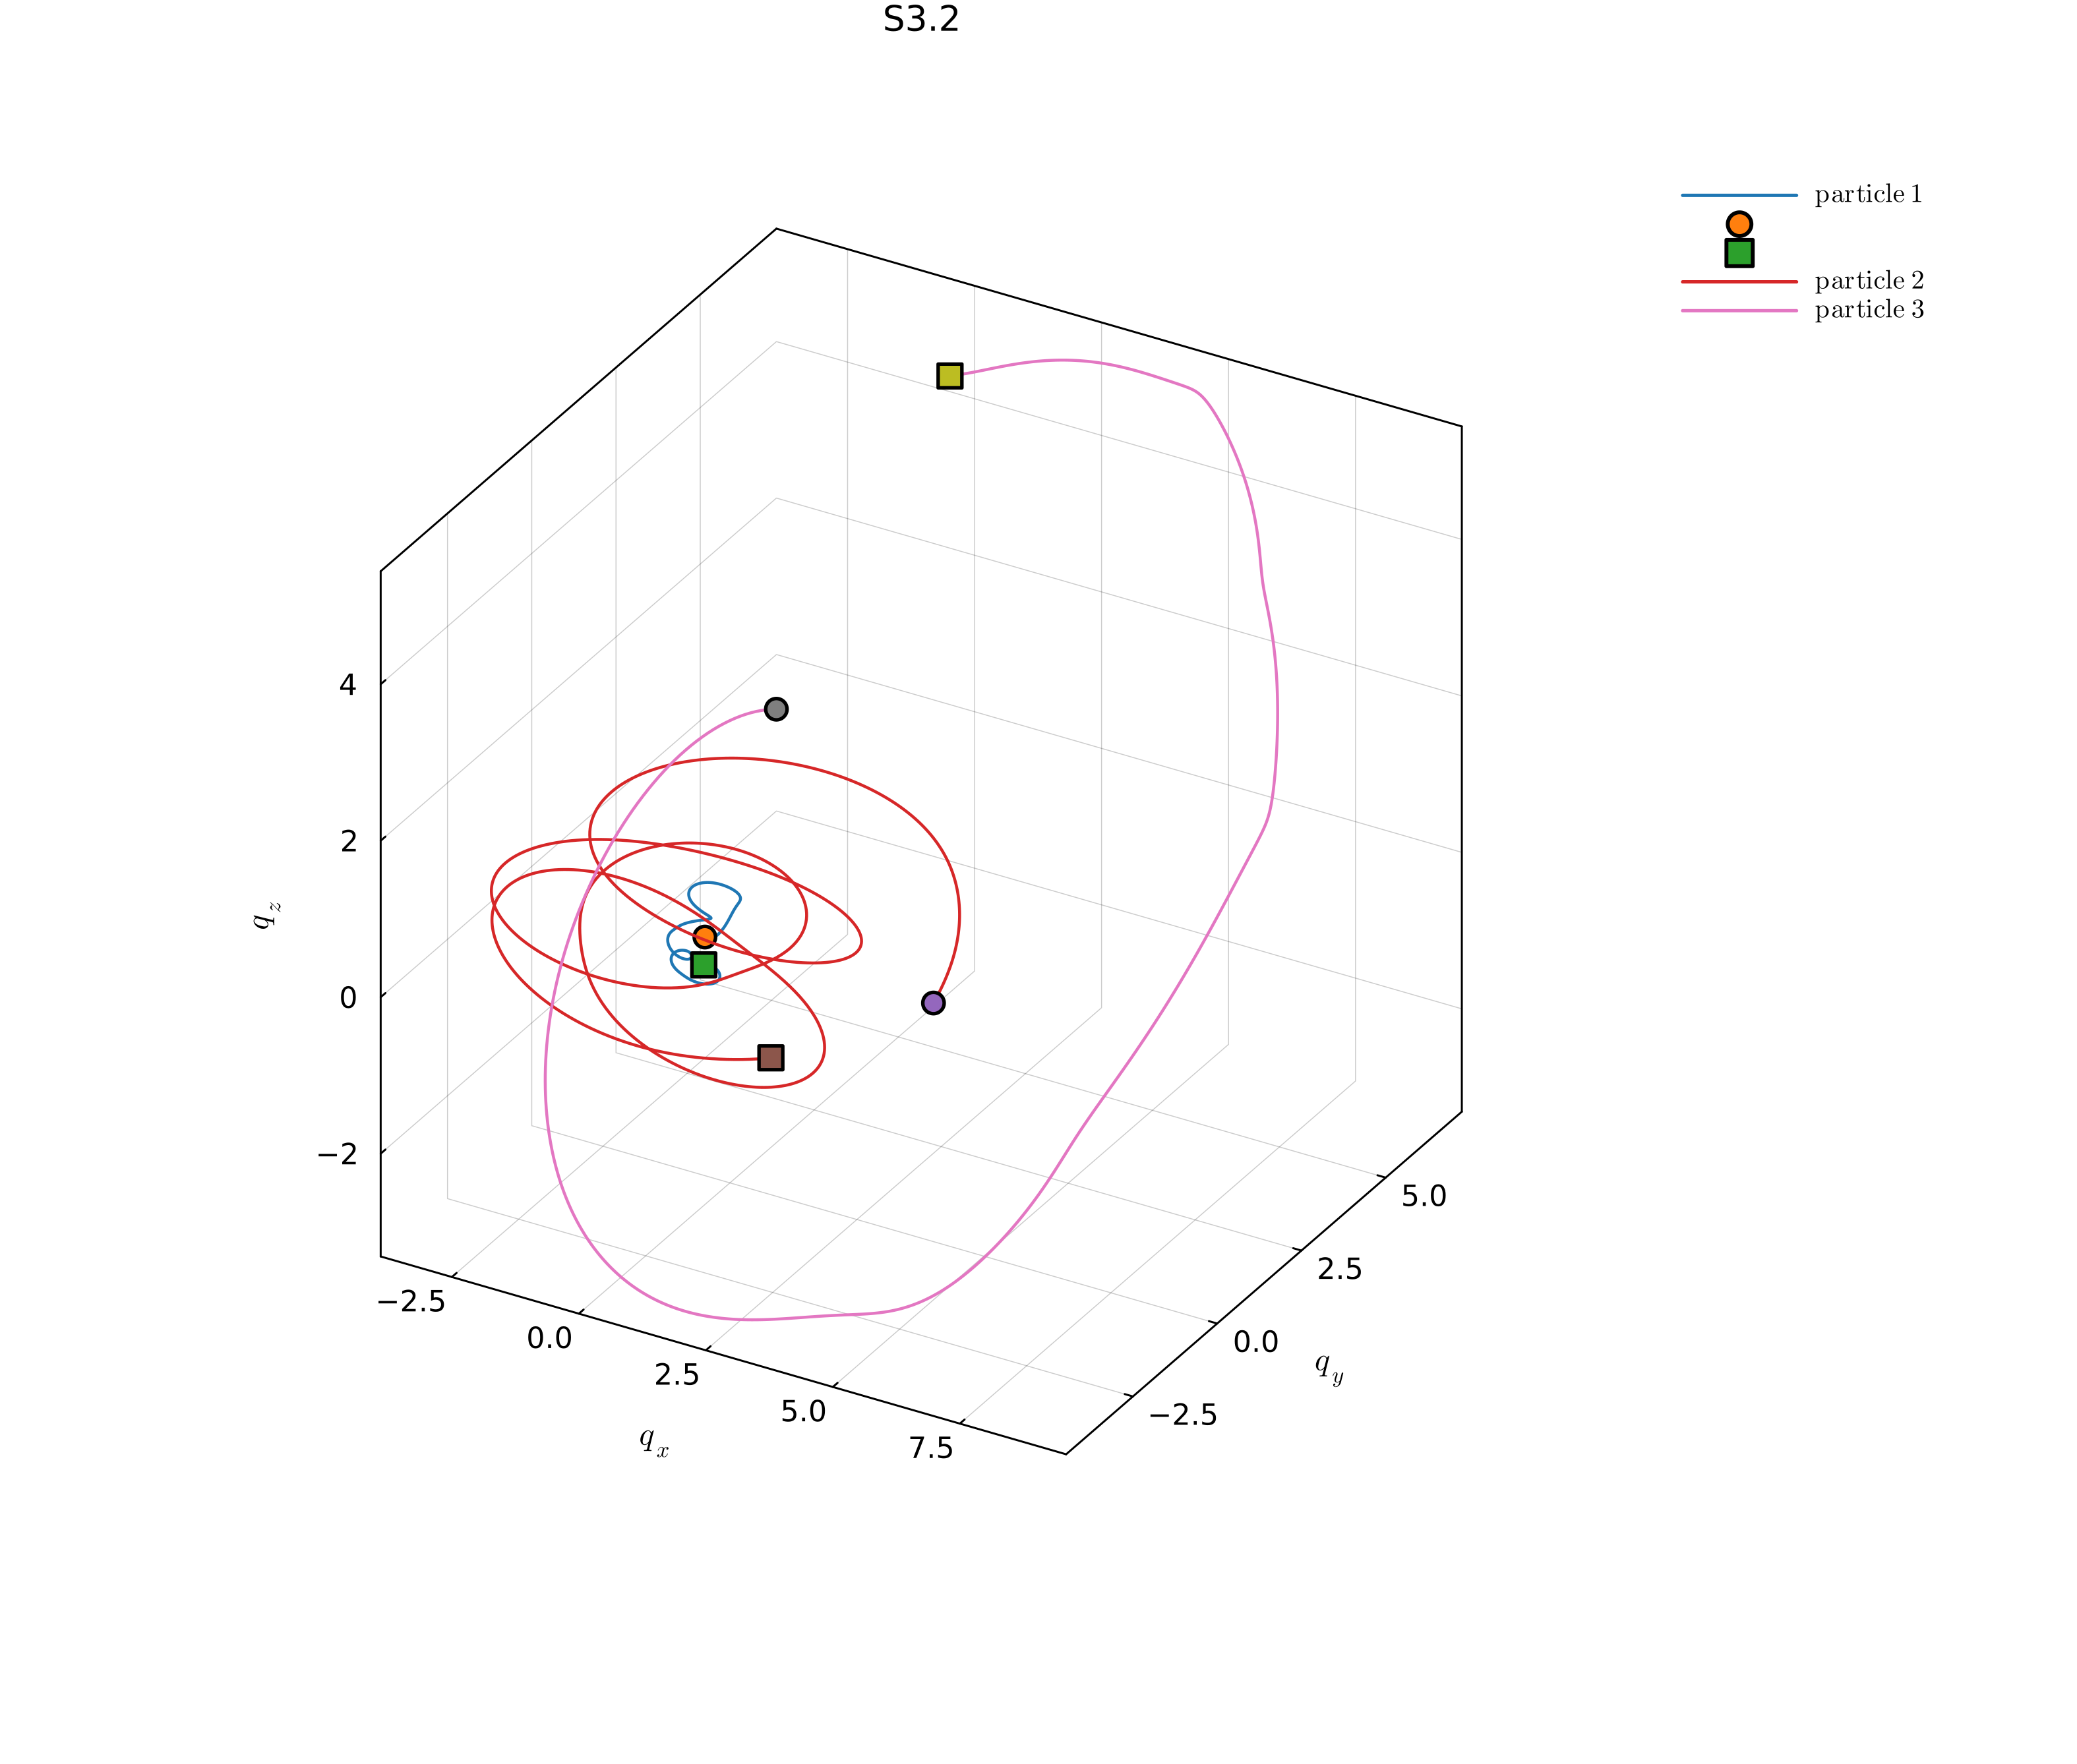

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [12]:
c = 1.0
orb = [
    Orbiter(m=1.0, q=+1.0, r=4.5, θ=π/2,          φ=0.0,      v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=1.0, q=+1.0, r=3.0, θ=deg2rad(45),  φ=π/2,      v_t_frac=1.0, v_r_frac=0.0),
]
ic = central_orbiter_system(c=c, m_c=10.0, q_c=-3.0, orbiters=orb, label="S3.2")
T_inner, T_out = inner_outer_periods(orb, 10.0, -3.0, c)
r = run_scenario("S3.2", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S3.2"] = print_summary_line(r)
plot_scenario_trajectory(r)


### S3.3 — asymmetric masses/charges (N=3)

[S3.3] N=3 ok E0=-0.478 T_est=NaN T_nat=35.65 err%max=0.0001 bound=y ρ=1.48 periodic=n fail ejection (I[end]/I[1]=47.2)


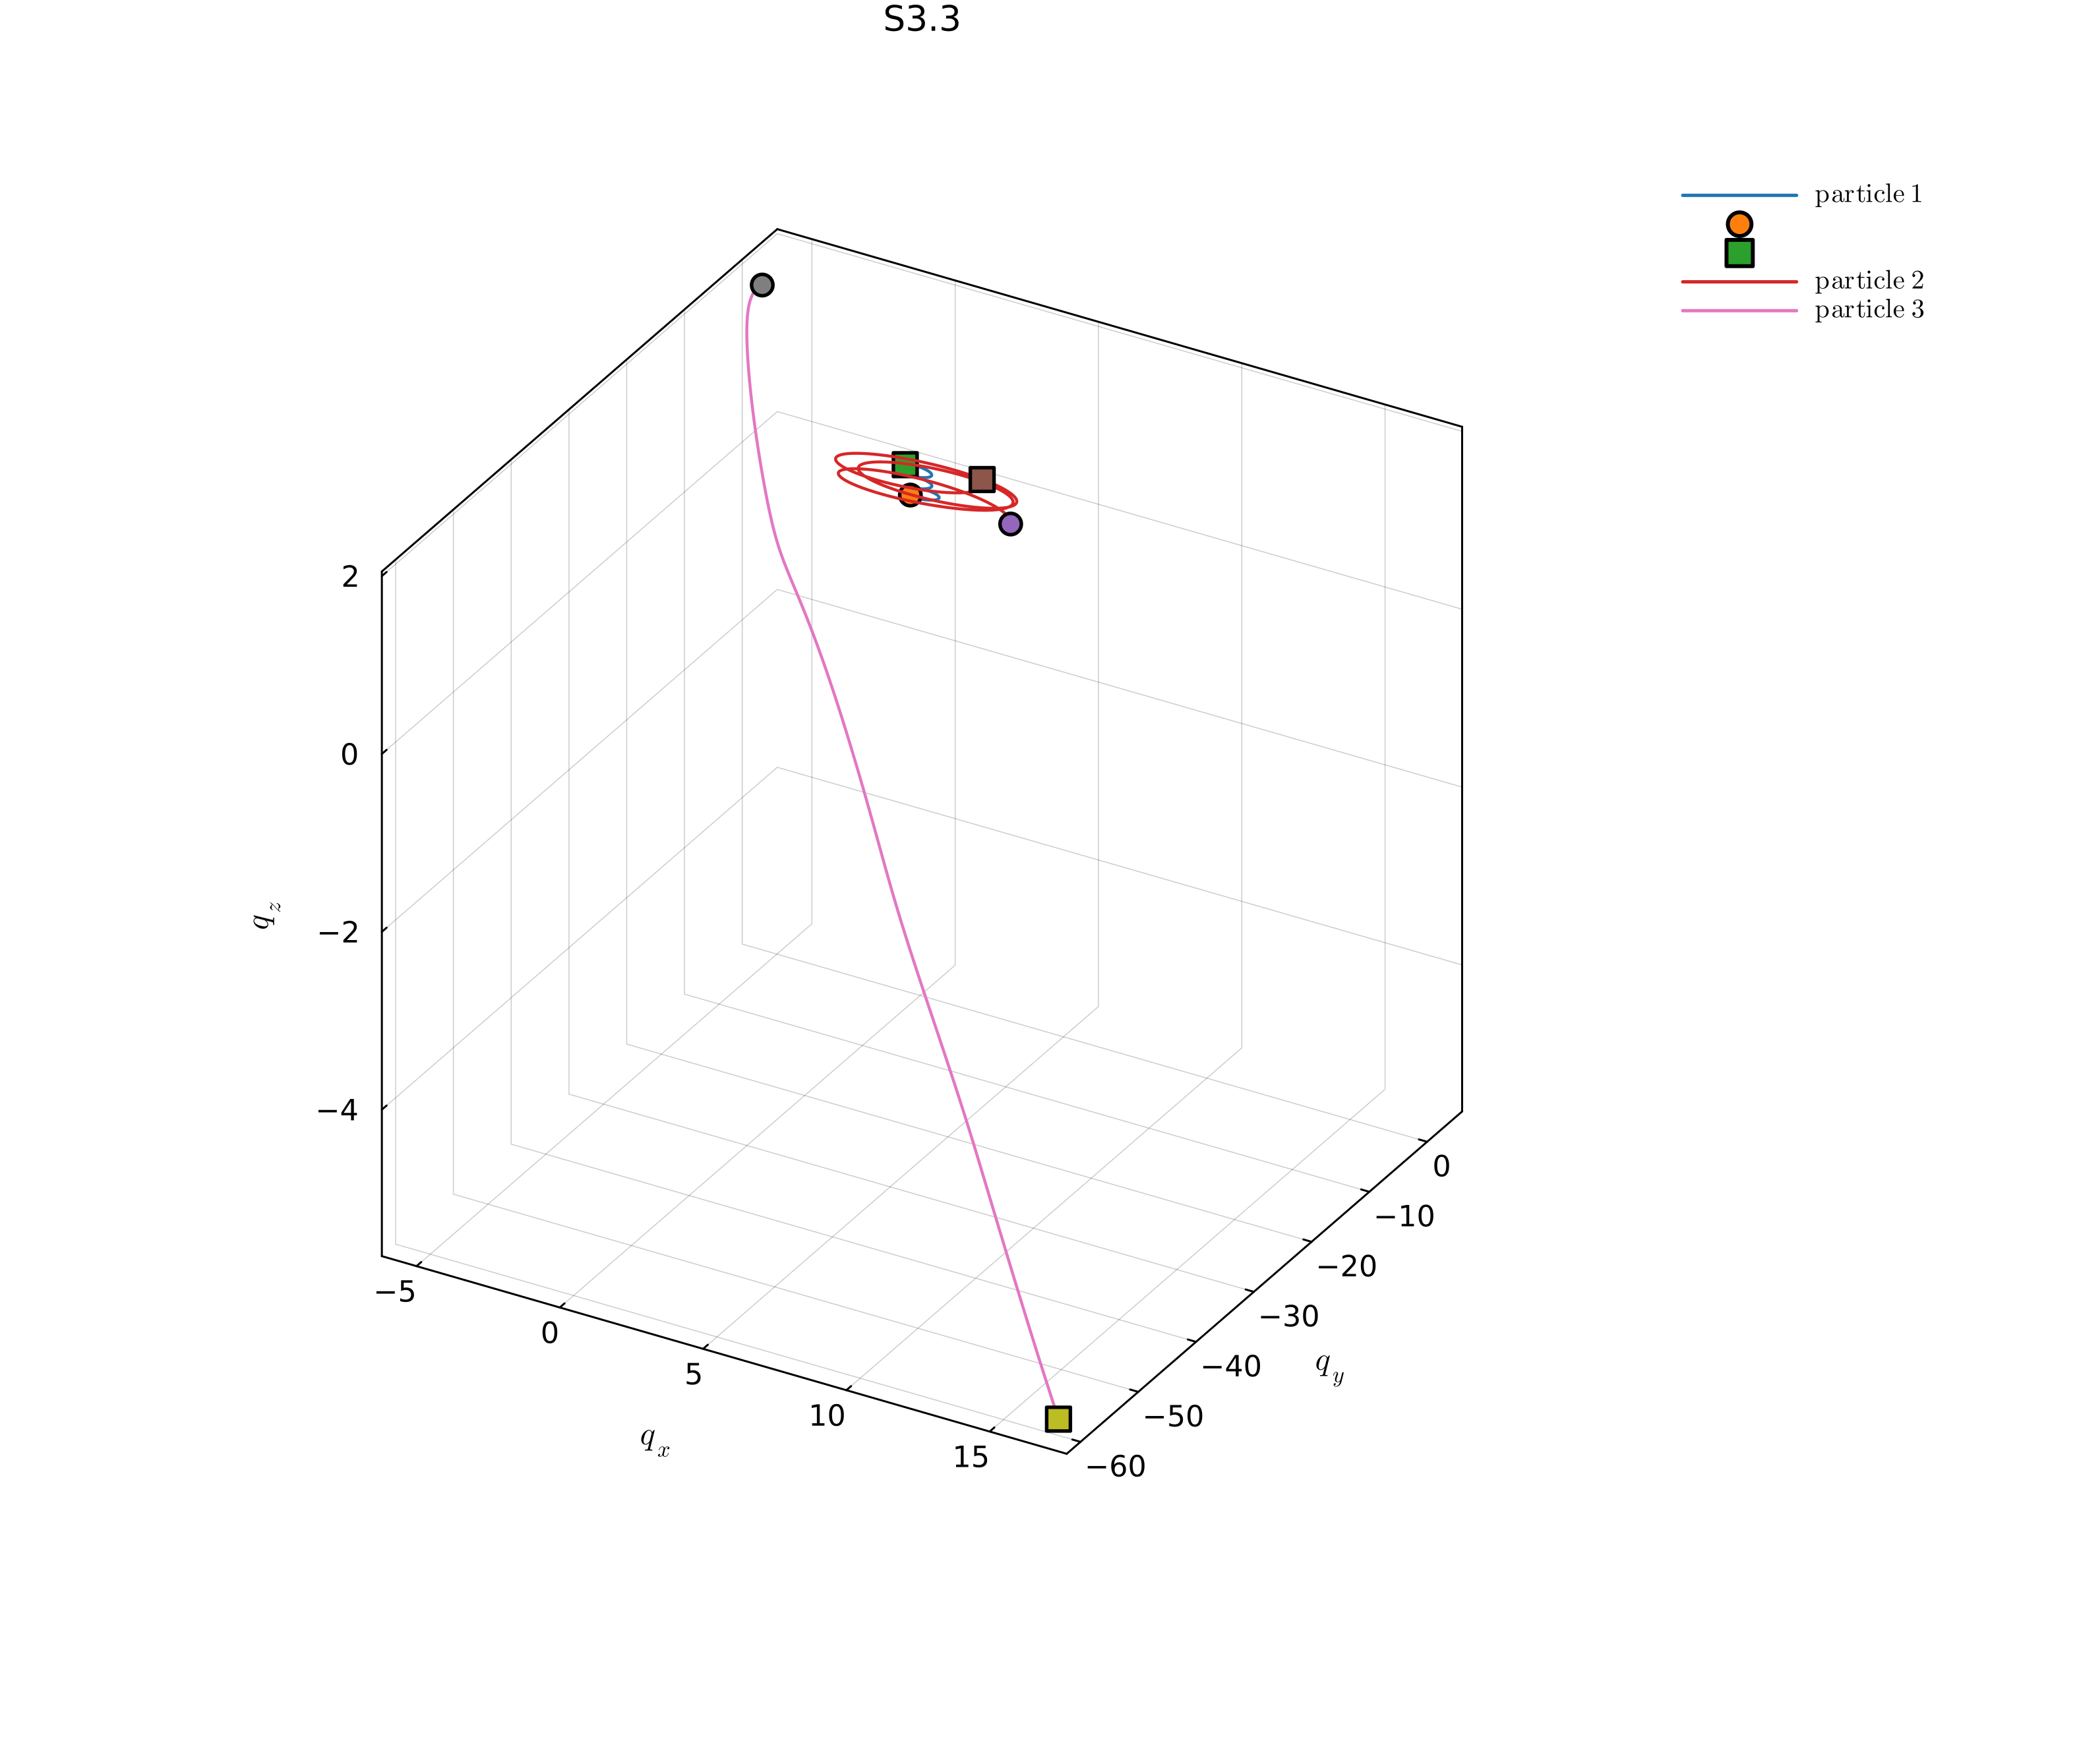

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [13]:
c = 1.0
orb = [
    Orbiter(m=2.0, q=+2.0, r=3.5, θ=π/2,           φ=0.0,    v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=0.4, q=+1.0, r=5.5, θ=deg2rad(70),   φ=π,      v_t_frac=1.0, v_r_frac=0.0),
]
ic = central_orbiter_system(c=c, m_c=12.0, q_c=-2.0, orbiters=orb, label="S3.3")
T_inner, T_out = inner_outer_periods(orb, 12.0, -2.0, c)
r = run_scenario("S3.3", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S3.3"] = print_summary_line(r)
plot_scenario_trajectory(r)


### S4.1 — three near-coplanar orbiters (N=4)

[S4.1] N=4 ok E0=-0.642 T_est=NaN T_nat=51.62 err%max=0.0004 bound=y ρ=1.56 periodic=n fail ejection (I[end]/I[1]=41.9)


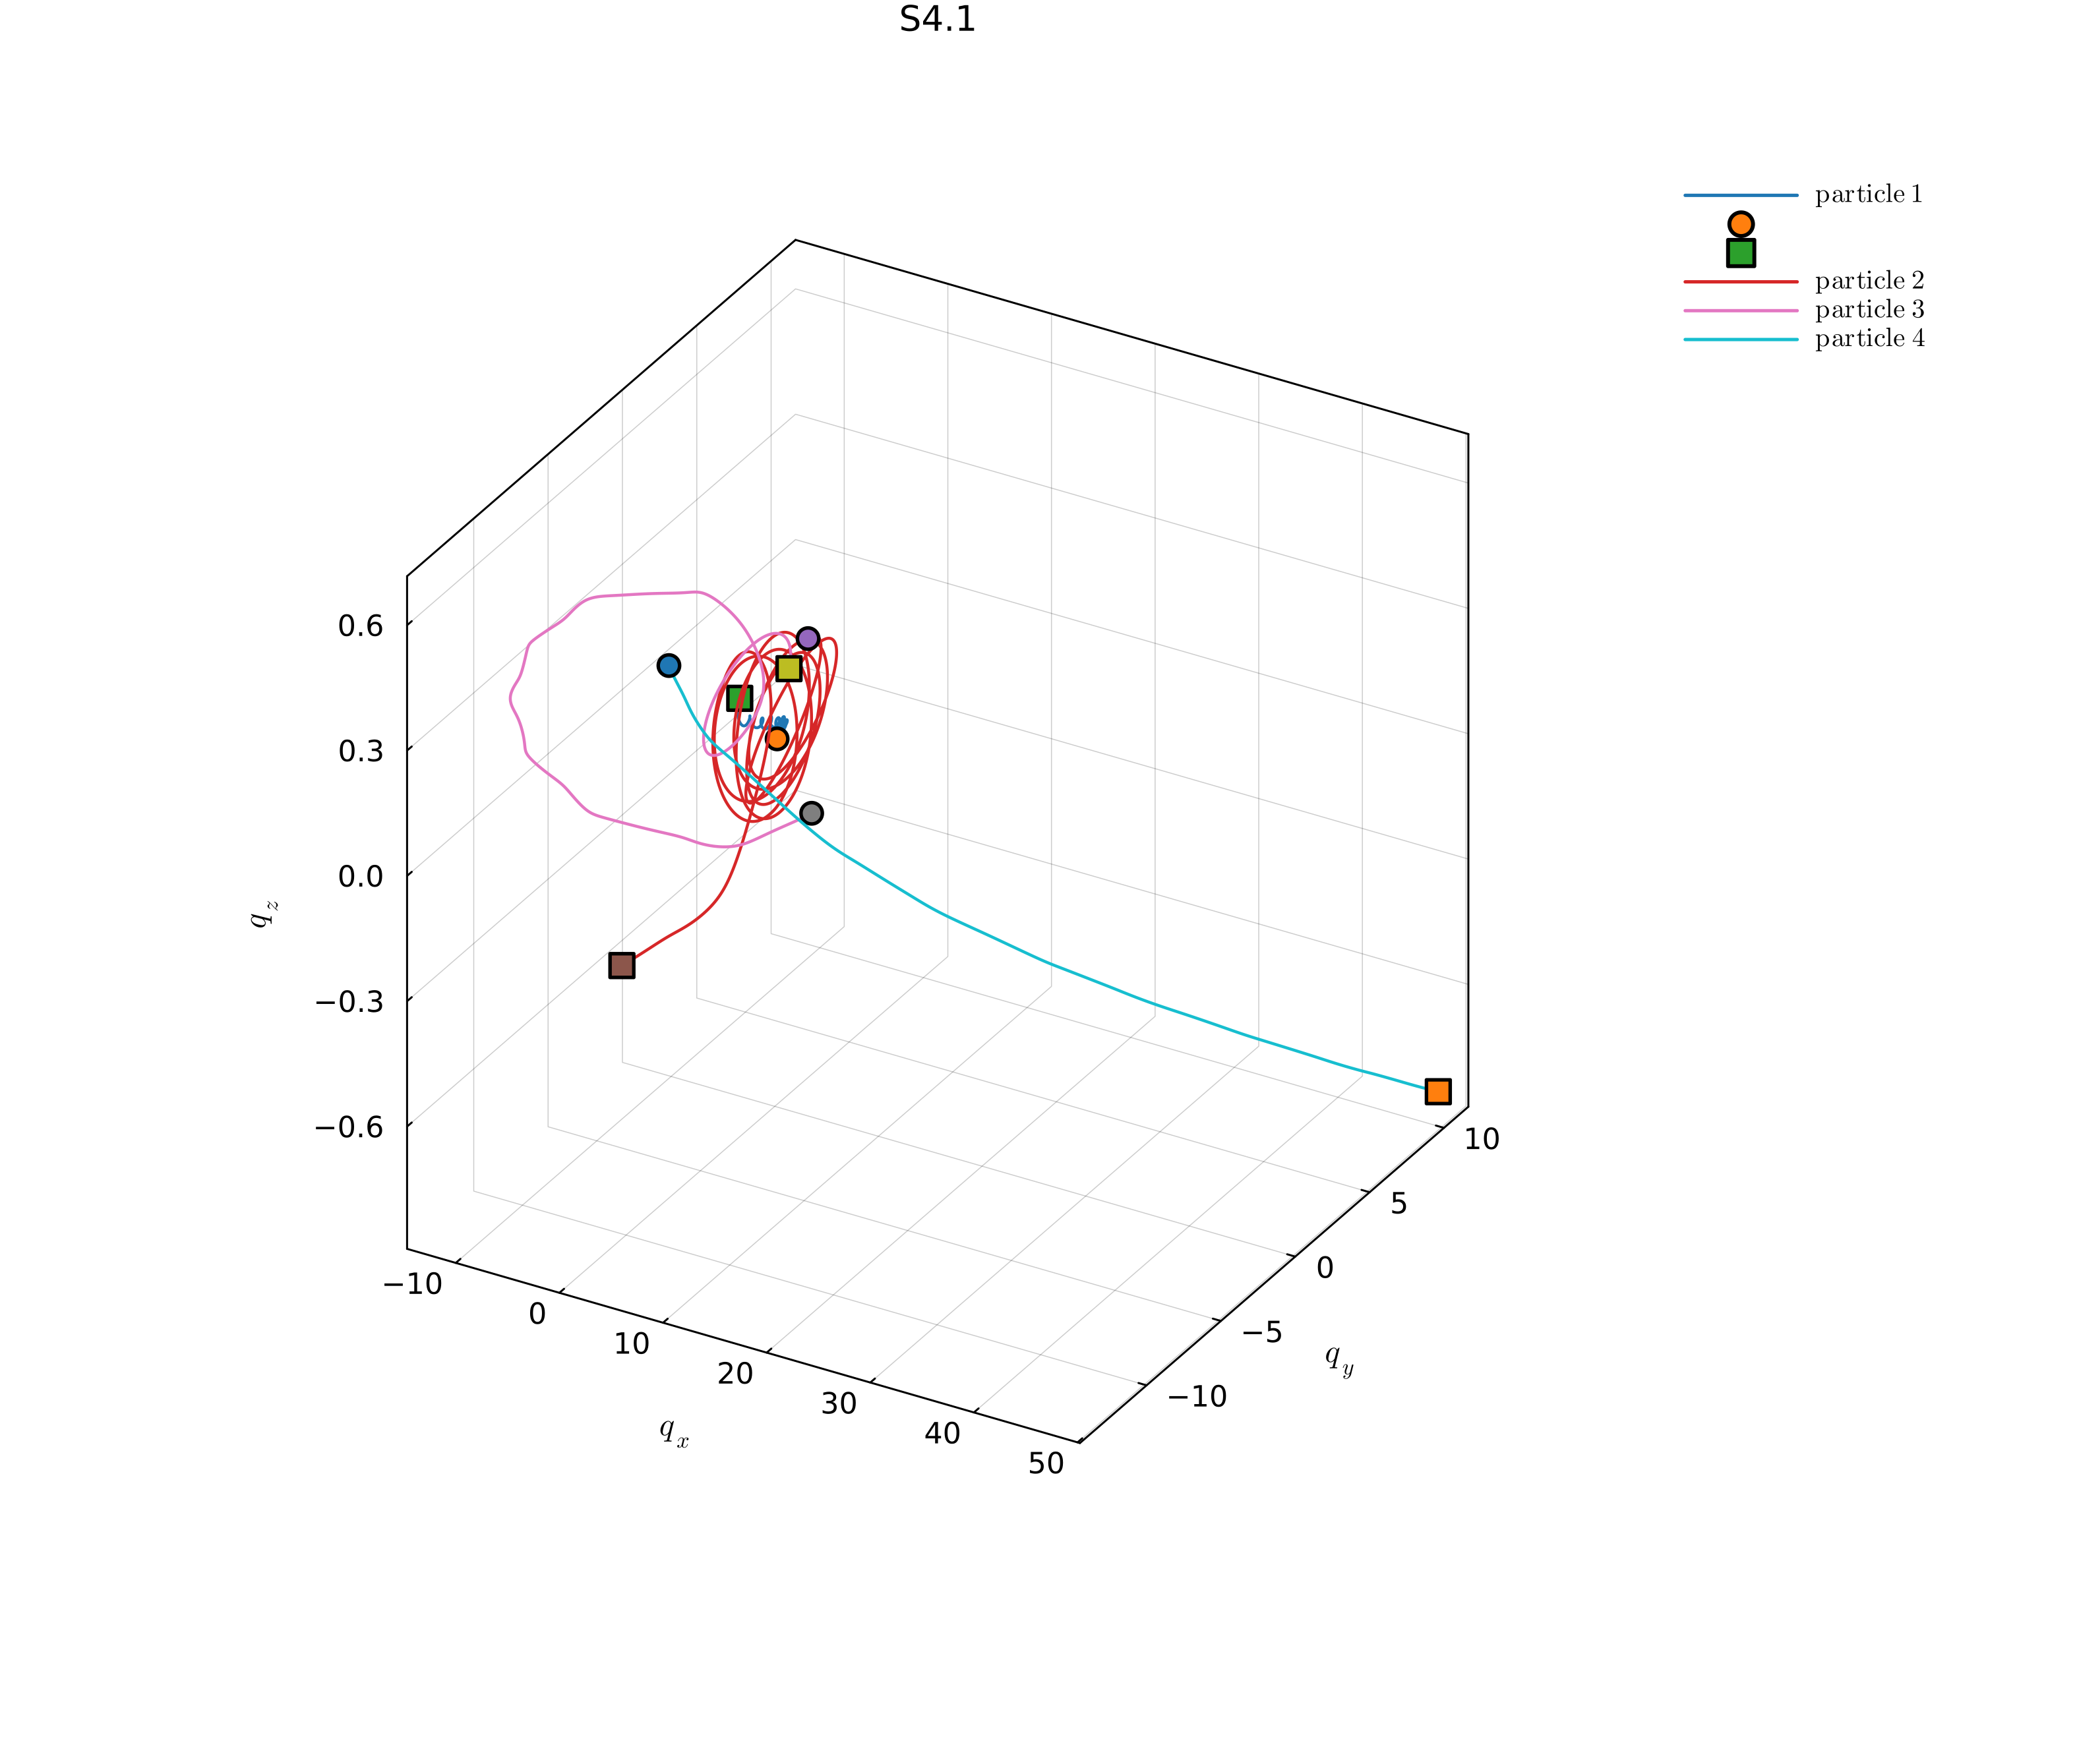

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [14]:
c = 1.0
orb = [
    Orbiter(m=1.0, q=+1.0, r=3.0, θ=π/2-deg2rad(5),  φ=0.0,    v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=1.0, q=+1.0, r=4.5, θ=π/2+deg2rad(4),  φ=2π/3,   v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=1.0, q=+1.0, r=6.0, θ=π/2-deg2rad(3),  φ=4π/3,   v_t_frac=1.0, v_r_frac=0.0),
]
ic = central_orbiter_system(c=c, m_c=15.0, q_c=-3.0, orbiters=orb, label="S4.1")
T_inner, T_out = inner_outer_periods(orb, 15.0, -3.0, c)
r = run_scenario("S4.1", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S4.1"] = print_summary_line(r)
plot_scenario_trajectory(r)


### S4.2 — three orthogonal-plane orbits (N=4)

[S4.2] N=4 ok E0=-0.664 T_est=NaN T_nat=28.10 err%max=1.0130 bound=y ρ=1.02 periodic=n fail ejection (I[end]/I[1]=32.2)


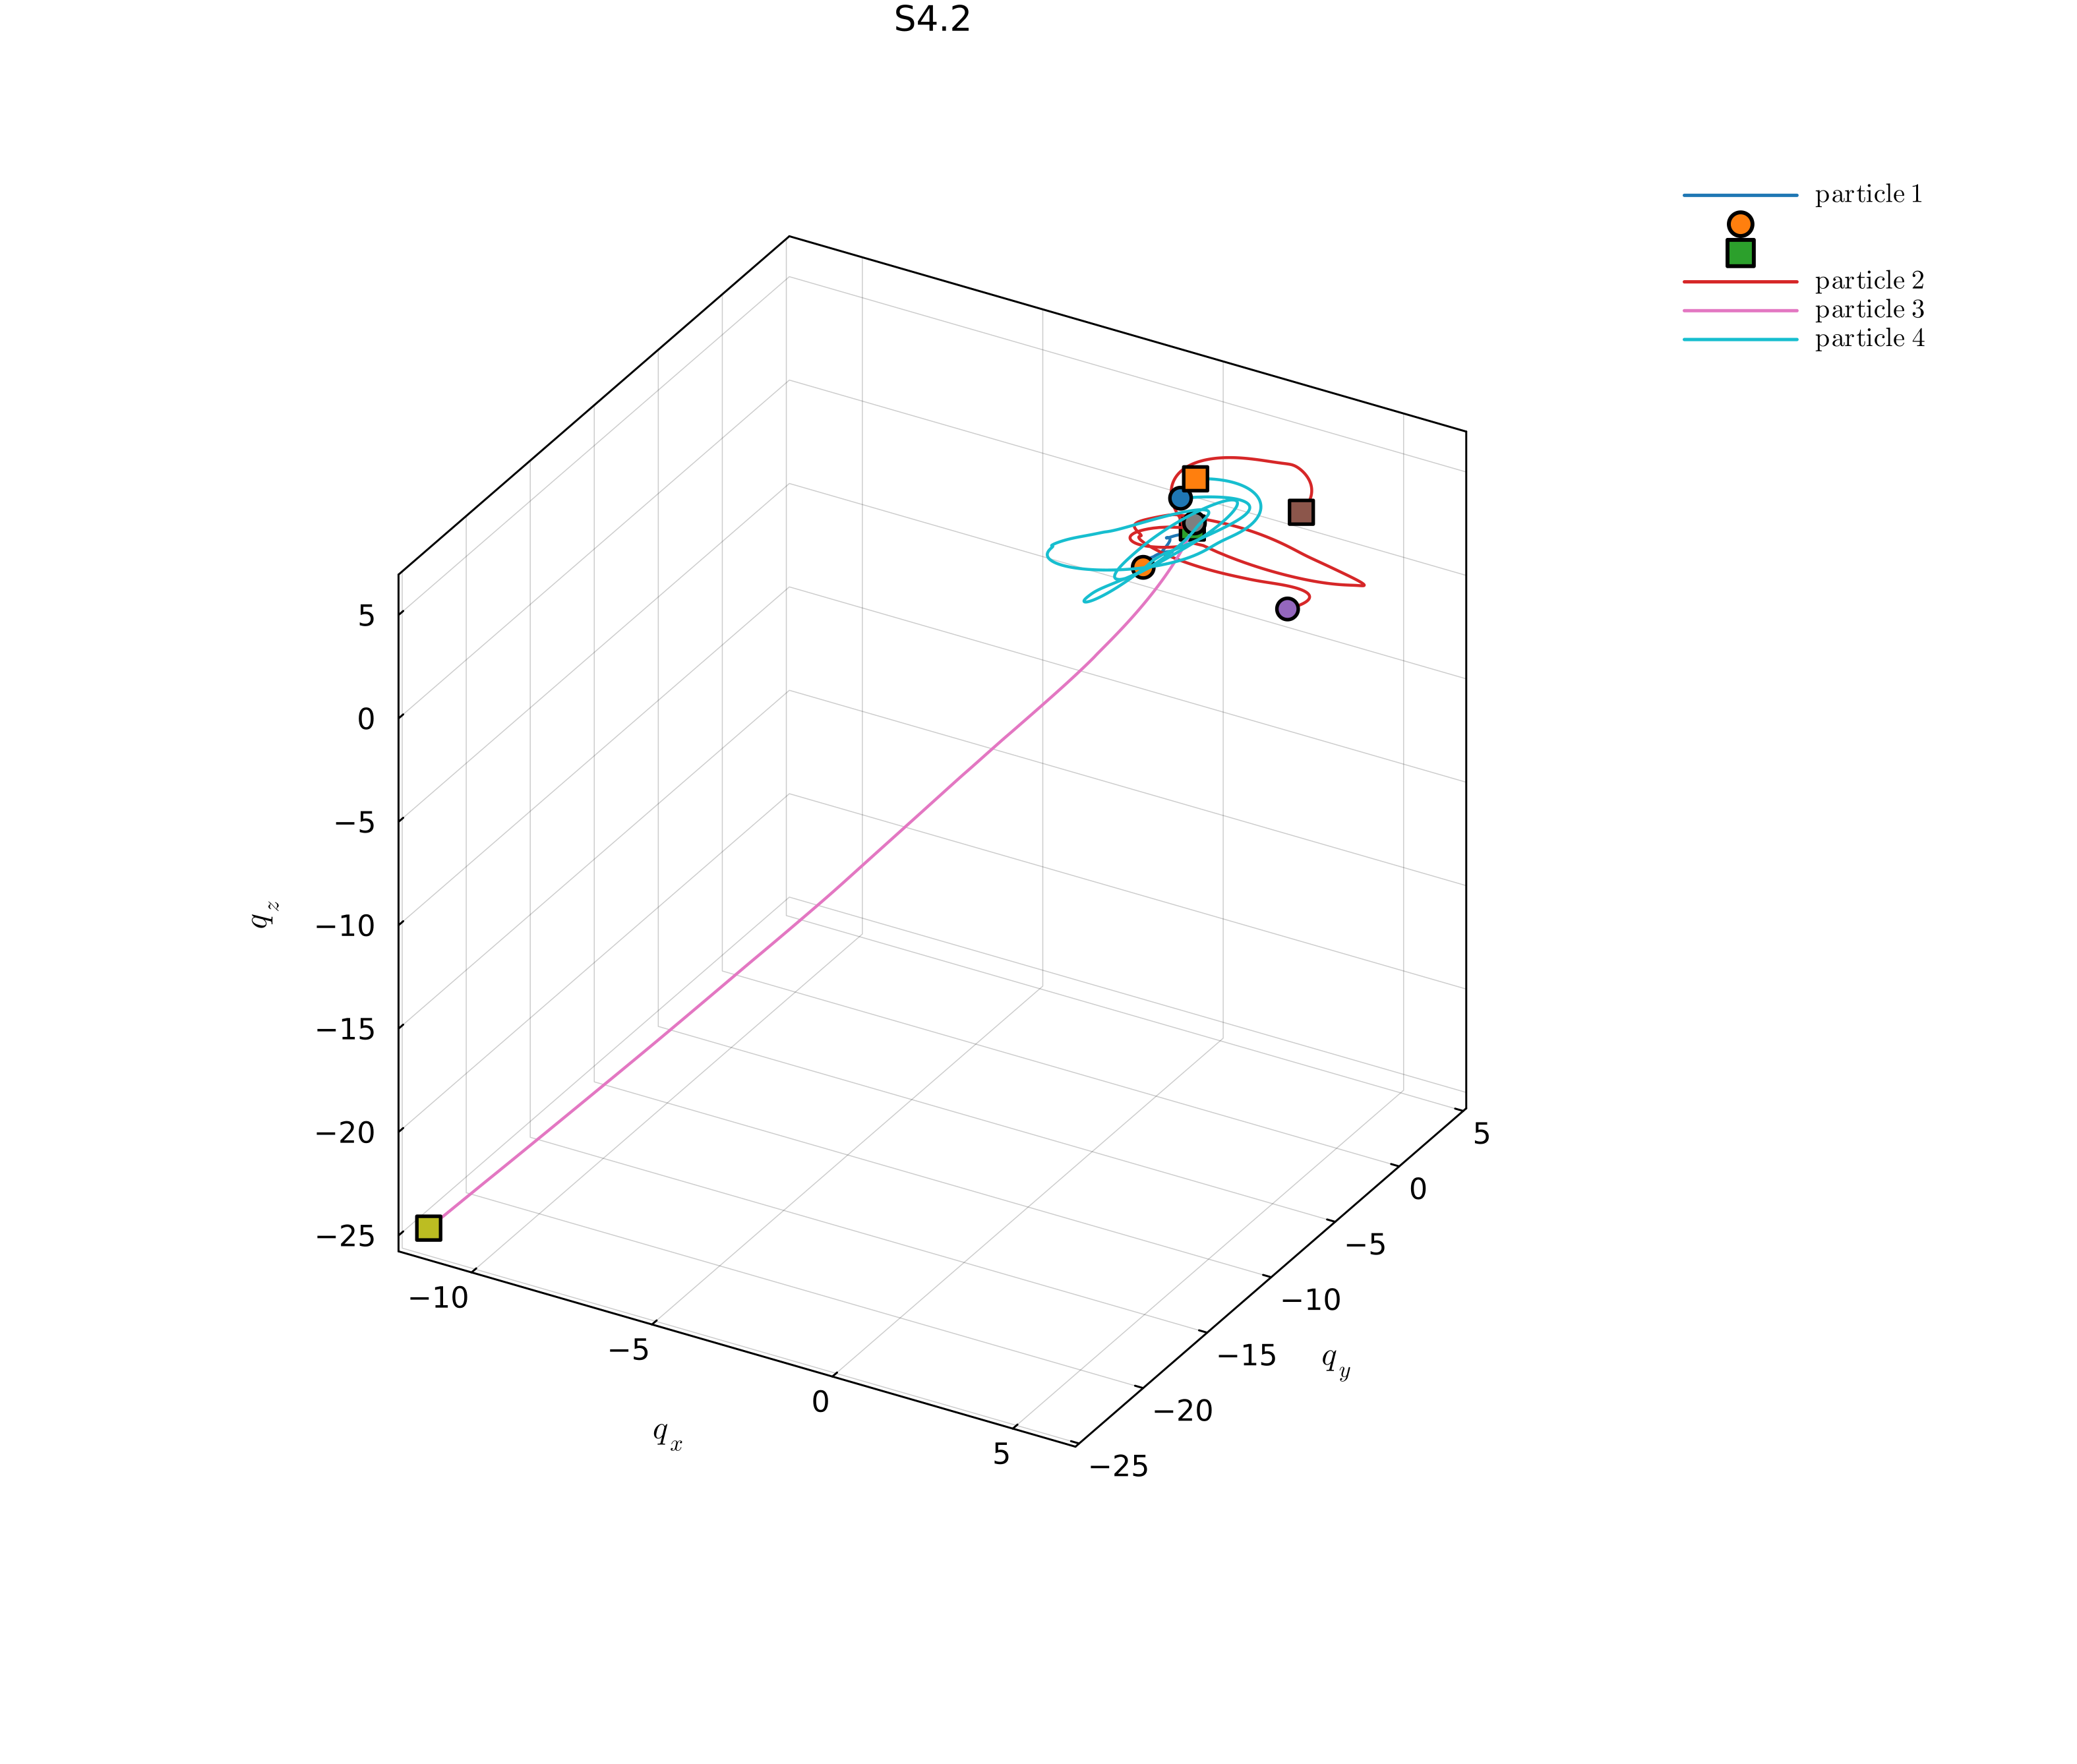

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [15]:
c = 1.0
orb = [
    Orbiter(m=1.0, q=+1.0, r=4.0, θ=π/2,       φ=0.0,  v_t_frac=1.0, v_r_frac=0.0, tilt=0.0),
    Orbiter(m=1.0, q=+1.0, r=4.0, θ=π/2,       φ=π/2,  v_t_frac=1.0, v_r_frac=0.0, tilt=π/2),
    Orbiter(m=1.0, q=+1.0, r=4.0, θ=deg2rad(15), φ=0.0, v_t_frac=1.0, v_r_frac=0.0, tilt=π/4),
]
ic = central_orbiter_system(c=c, m_c=15.0, q_c=-3.0, orbiters=orb, label="S4.2")
T_inner, T_out = inner_outer_periods(orb, 15.0, -3.0, c)
r = run_scenario("S4.2", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S4.2"] = print_summary_line(r)
plot_scenario_trajectory(r)


### S4.3 — asymmetric masses (N=4)

[S4.3] N=4 ok E0=-0.544 T_est=NaN T_nat=46.92 err%max=0.0001 bound=y ρ=3.23 periodic=n fail ejection (I[end]/I[1]=35.7)


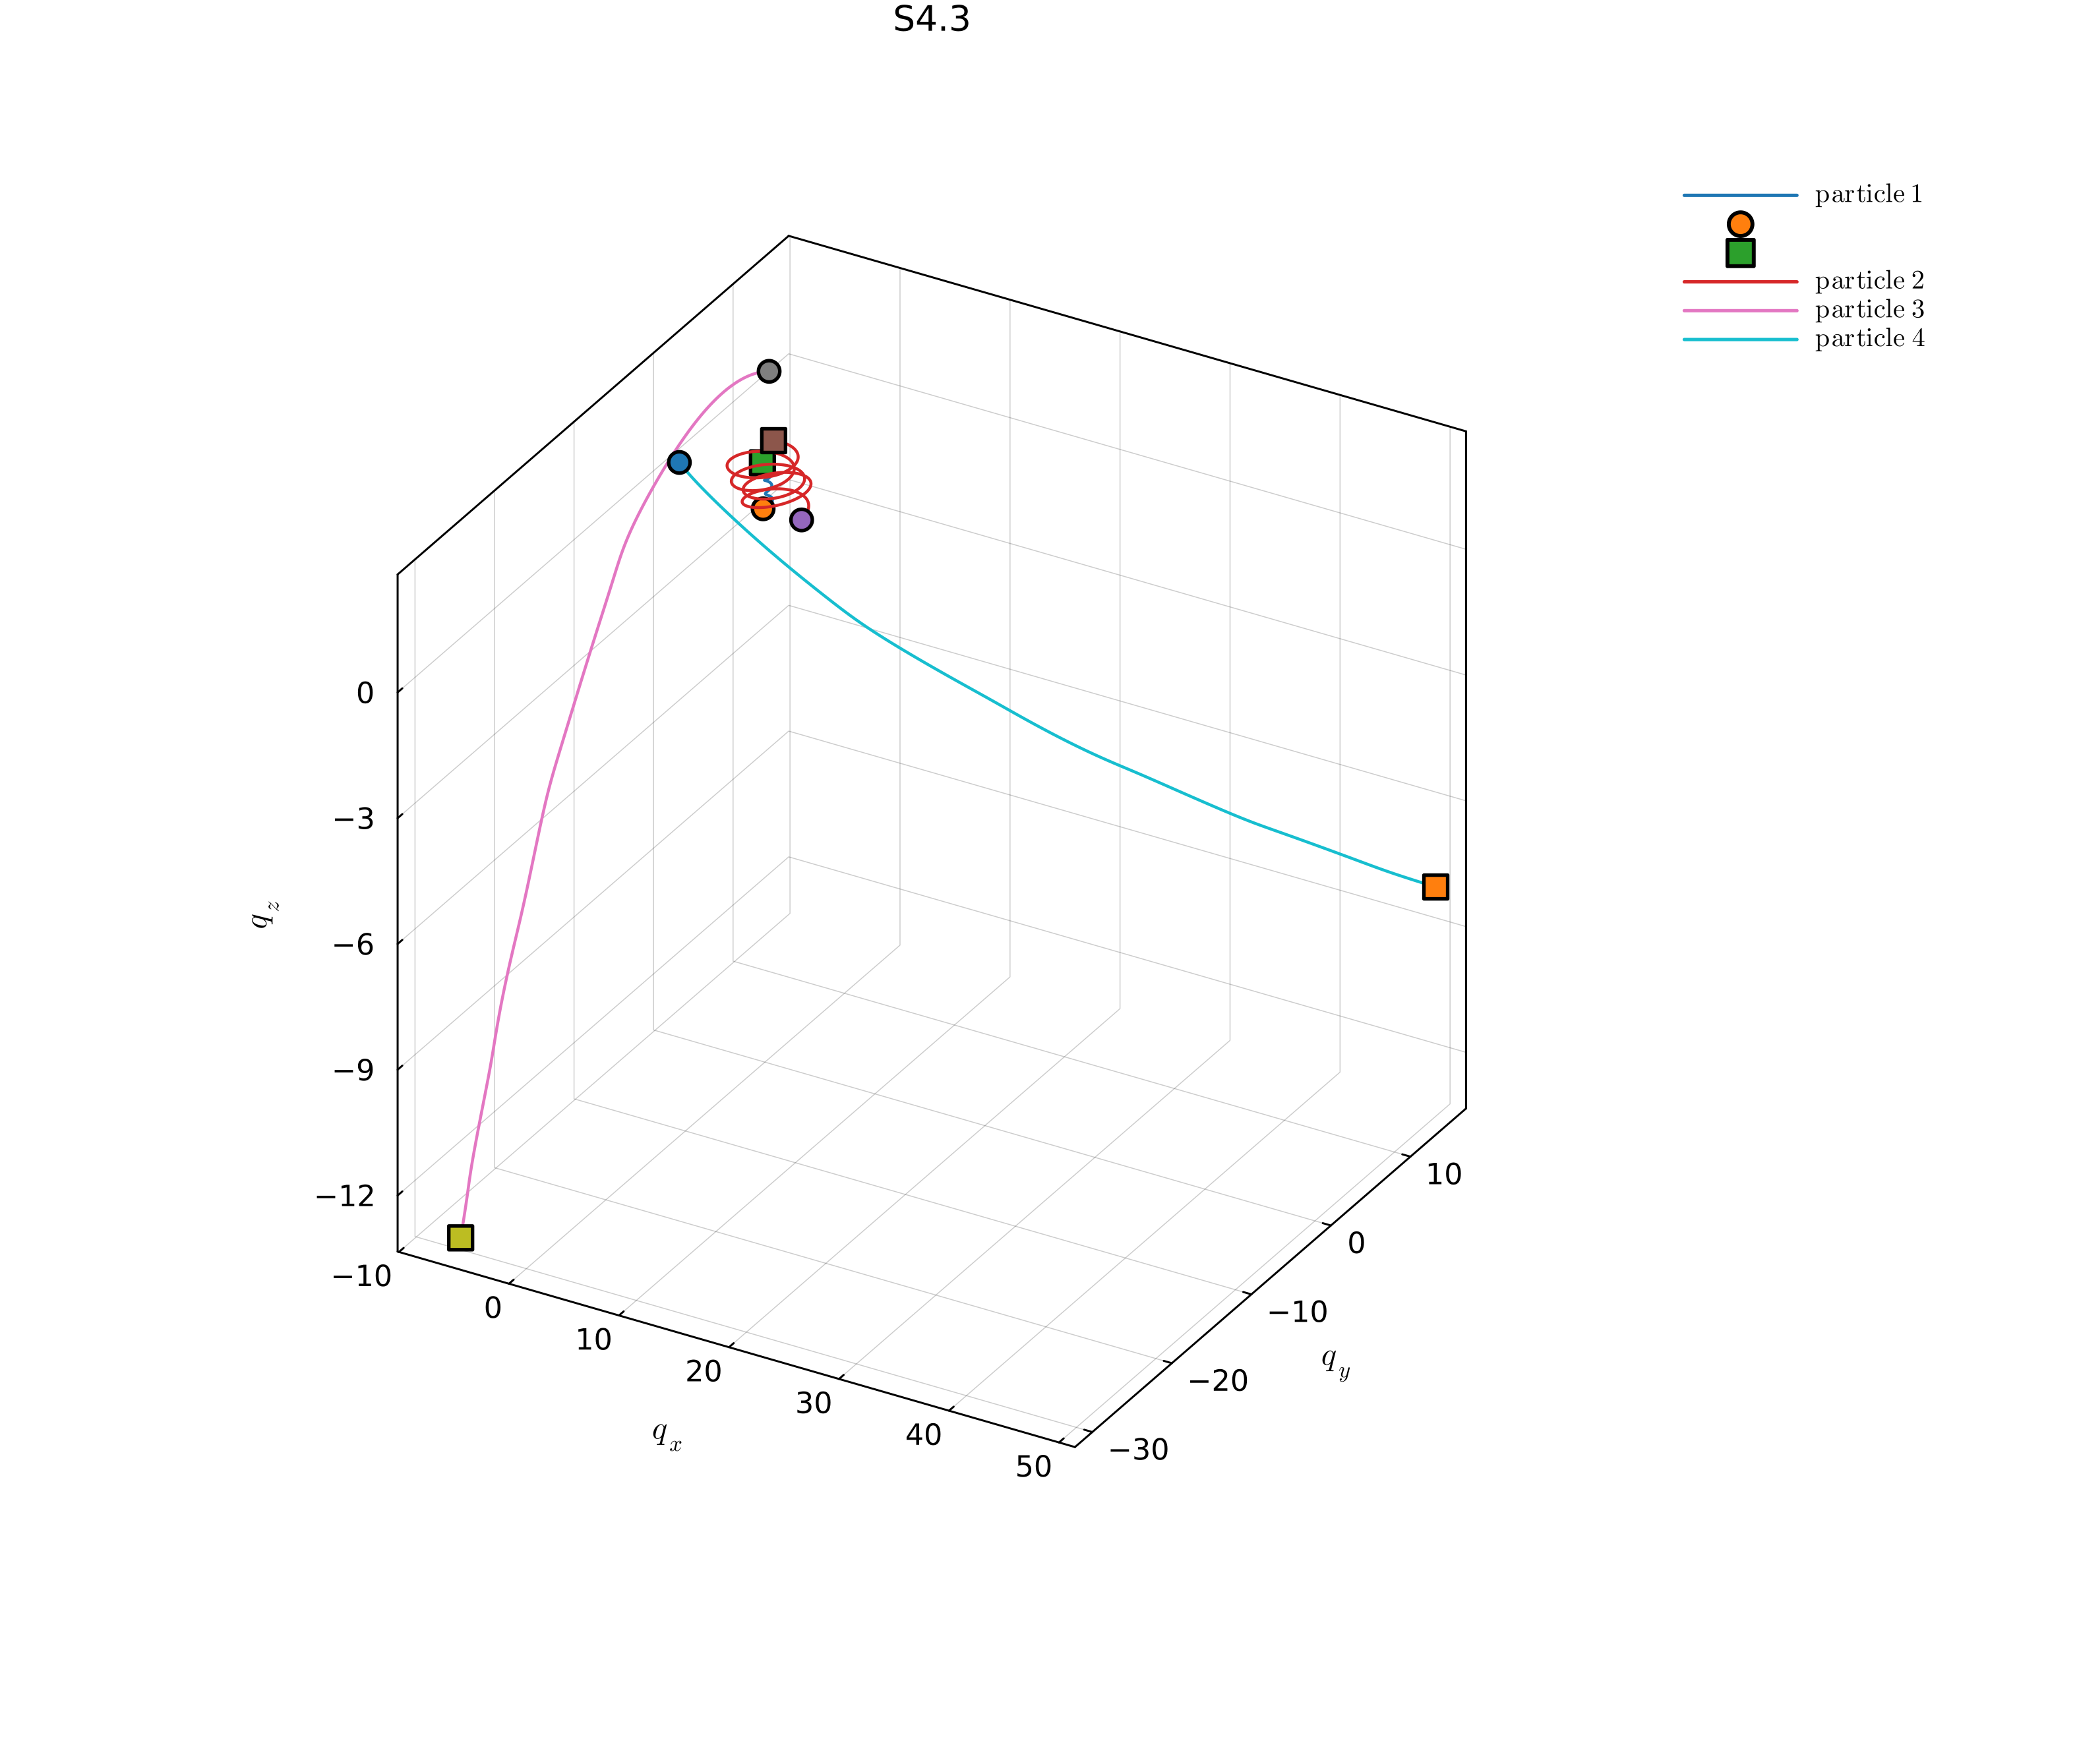

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [16]:
c = 1.0
orb = [
    Orbiter(m=2.0, q=+1.0, r=3.5, θ=π/2,           φ=0.0,     v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=1.0, q=+1.0, r=5.0, θ=deg2rad(60),   φ=2π/3,    v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=0.5, q=+1.0, r=7.0, θ=deg2rad(75),   φ=4π/3,    v_t_frac=1.0, v_r_frac=0.0),
]
ic = central_orbiter_system(c=c, m_c=20.0, q_c=-3.0, orbiters=orb, label="S4.3")
T_inner, T_out = inner_outer_periods(orb, 20.0, -3.0, c)
r = run_scenario("S4.3", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S4.3"] = print_summary_line(r)
plot_scenario_trajectory(r)


### S5.1 — four orbiters on tetrahedral directions (N=5)

[S5.1] N=5 ok E0=-1.061 T_est=NaN T_nat=29.04 err%max=0.0195 bound=y ρ=1.11 periodic=n fail ejection (I[end]/I[1]=19.0)


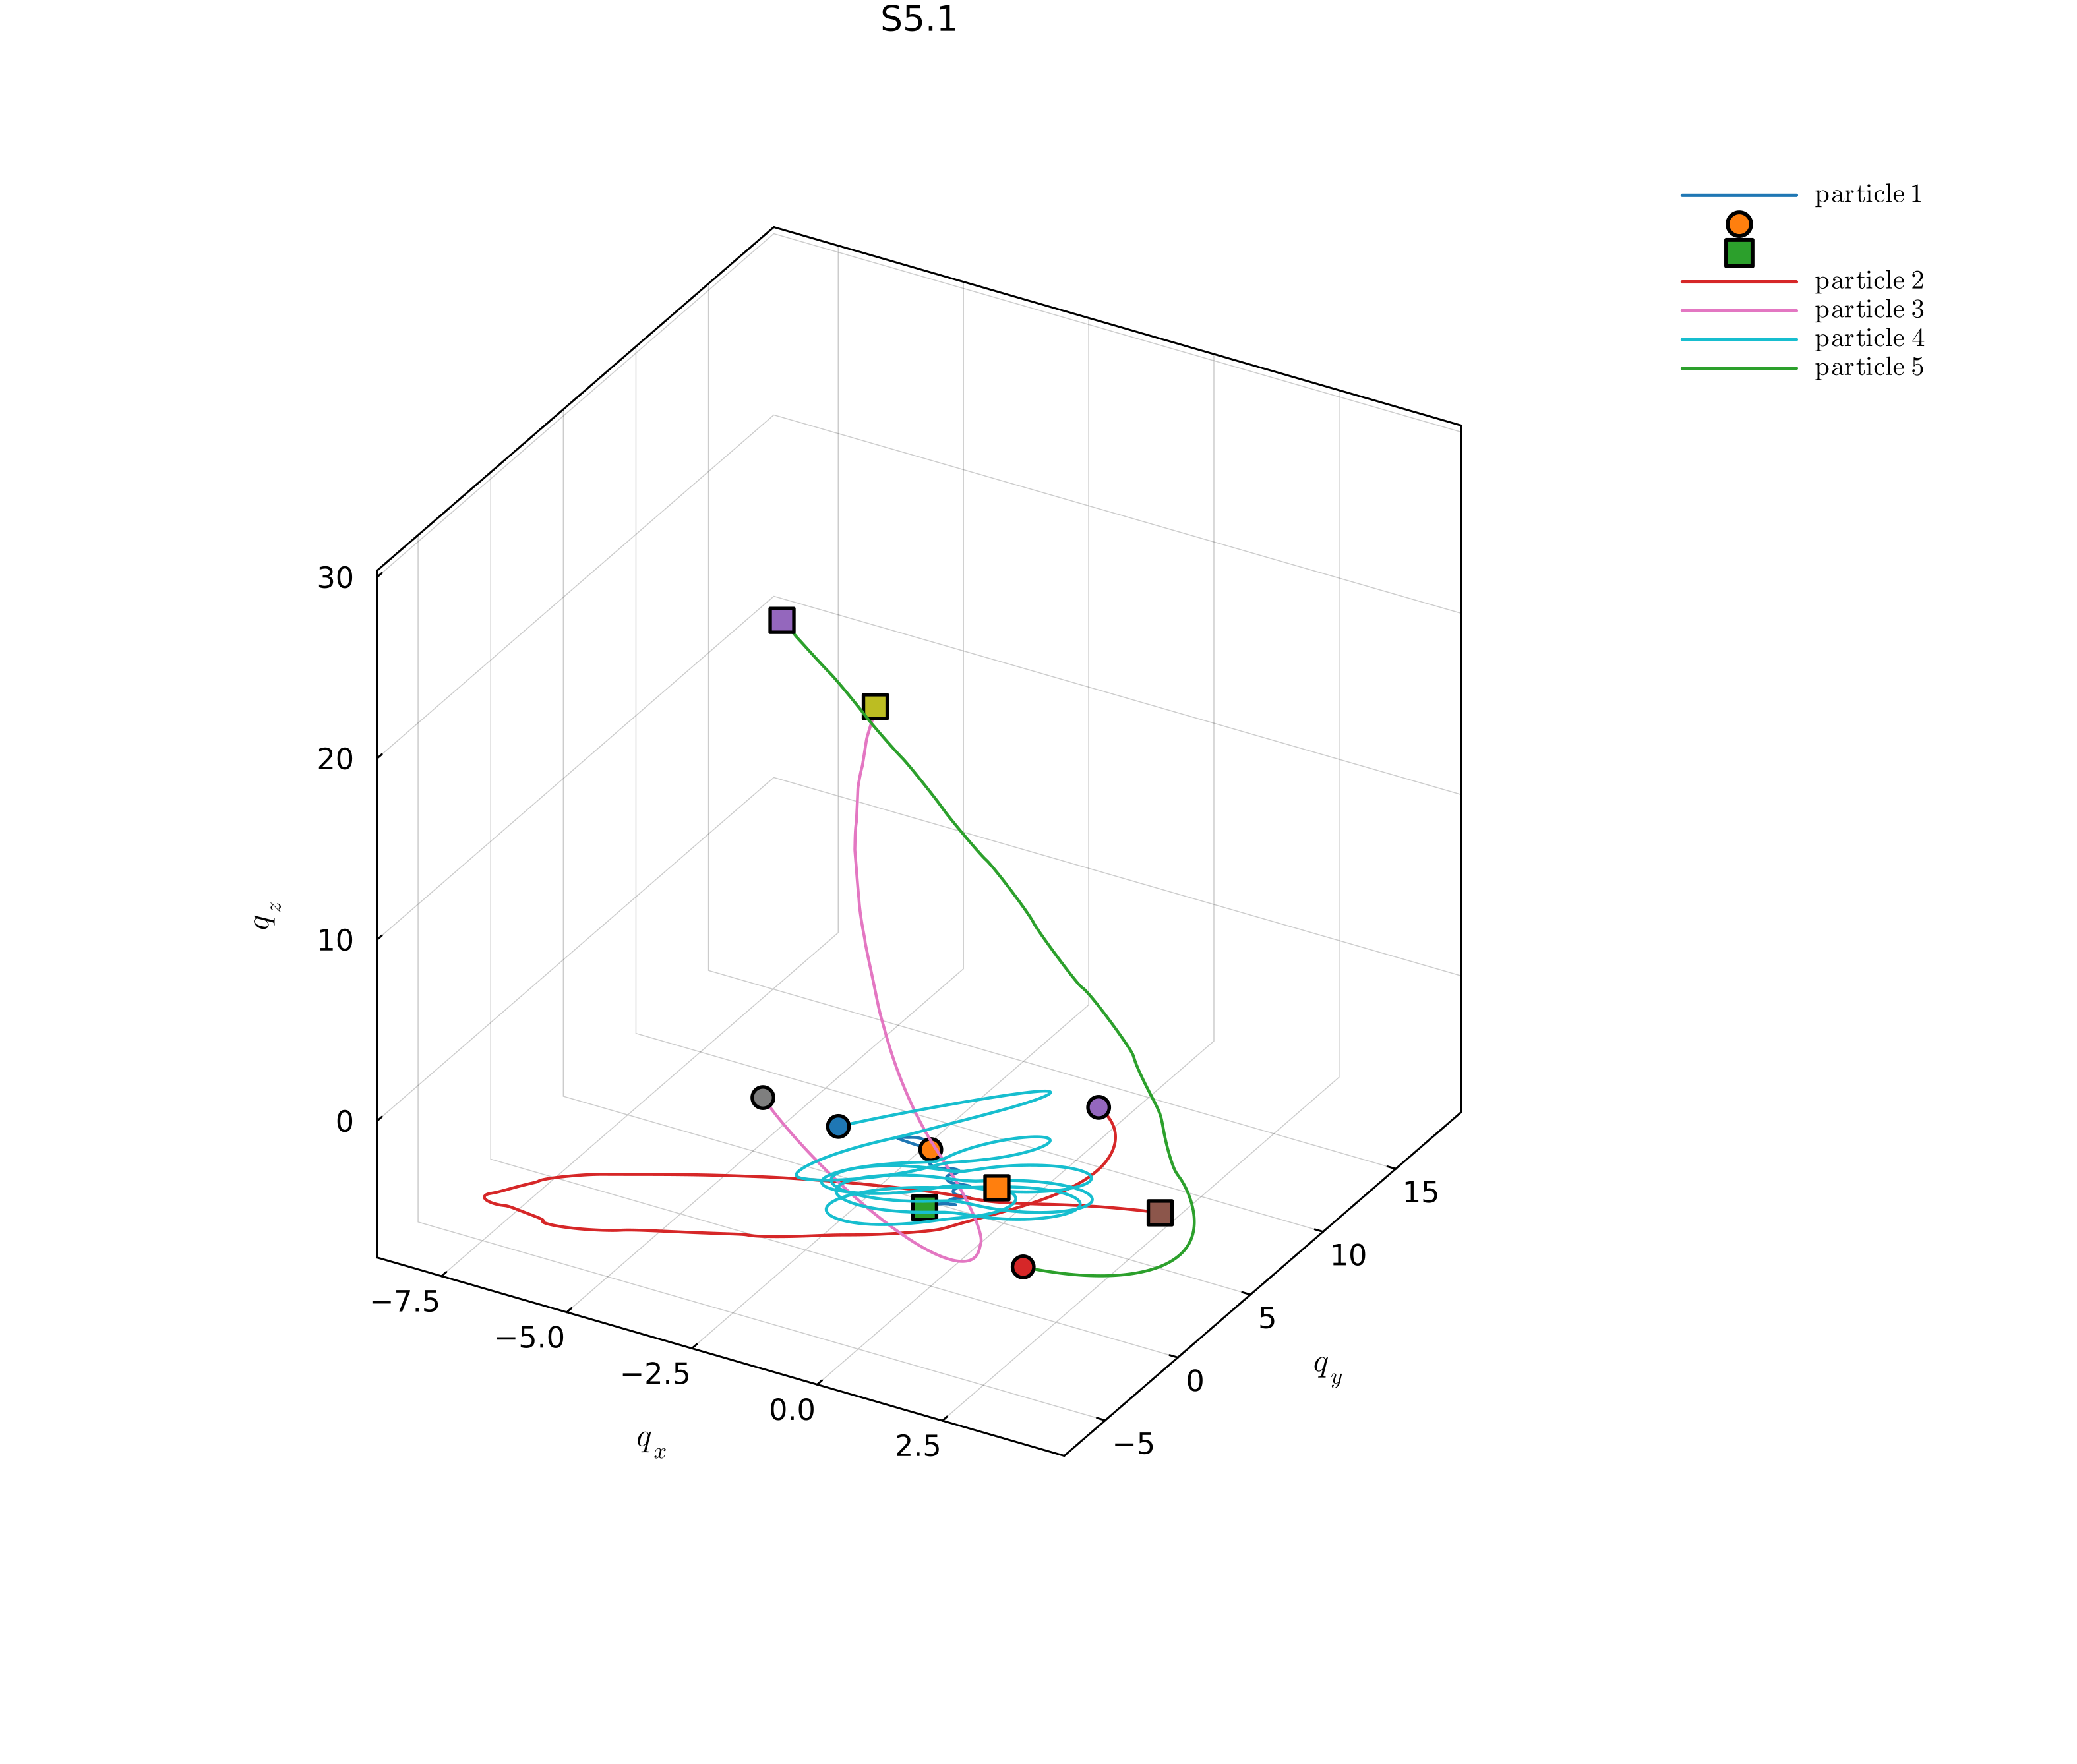

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [17]:
c = 1.0
tetra_dirs = [(+1.0,+1.0,+1.0), (-1.0,-1.0,+1.0), (-1.0,+1.0,-1.0), (+1.0,-1.0,-1.0)]
orb = Orbiter[]
for (i, (x,y,z)) in enumerate(tetra_dirs)
    d = [x,y,z] ./ sqrt(3)
    θ = acos(d[3]); φ = atan(d[2], d[1])
    push!(orb, Orbiter(m=1.0, q=+1.0, r=4.5, θ=θ, φ=φ,
                       v_t_frac=1.0, v_r_frac=0.0,
                       handedness=iseven(i) ? +1 : -1, tilt=deg2rad(15)))
end
ic = central_orbiter_system(c=c, m_c=15.0, q_c=-4.0, orbiters=orb, label="S5.1")
T_inner, T_out = inner_outer_periods(orb, 15.0, -4.0, c)
r = run_scenario("S5.1", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S5.1"] = print_summary_line(r)
plot_scenario_trajectory(r)


### S5.2 — four orbiters at hierarchical radii (N=5)

In [18]:
c = 1.0
orb = [
    Orbiter(m=1.0, q=+1.0, r=3.0, θ=π/2,           φ=0.0,       v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=1.0, q=+1.0, r=4.0, θ=deg2rad(60),   φ=π/2,       v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=1.0, q=+1.0, r=5.5, θ=deg2rad(120),  φ=π,         v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=1.0, q=+1.0, r=7.0, θ=deg2rad(75),   φ=3π/2,      v_t_frac=1.0, v_r_frac=0.0),
]
ic = central_orbiter_system(c=c, m_c=15.0, q_c=-4.0, orbiters=orb, label="S5.2")
T_inner, T_out = inner_outer_periods(orb, 15.0, -4.0, c)
r = run_scenario("S5.2", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S5.2"] = print_summary_line(r)
plot_scenario_trajectory(r)


[S5.2] N=5 solver_failure retcode=Failure t_end=44.117


### S5.3 — mixed-charge orbiters + Zöllner coupling (N=5)

[S5.3] N=5 ok E0=-0.901 T_est=NaN T_nat=45.66 err%max=2.5437 bound=y ρ=1.42 periodic=n fail ejection (I[end]/I[1]=91.4)


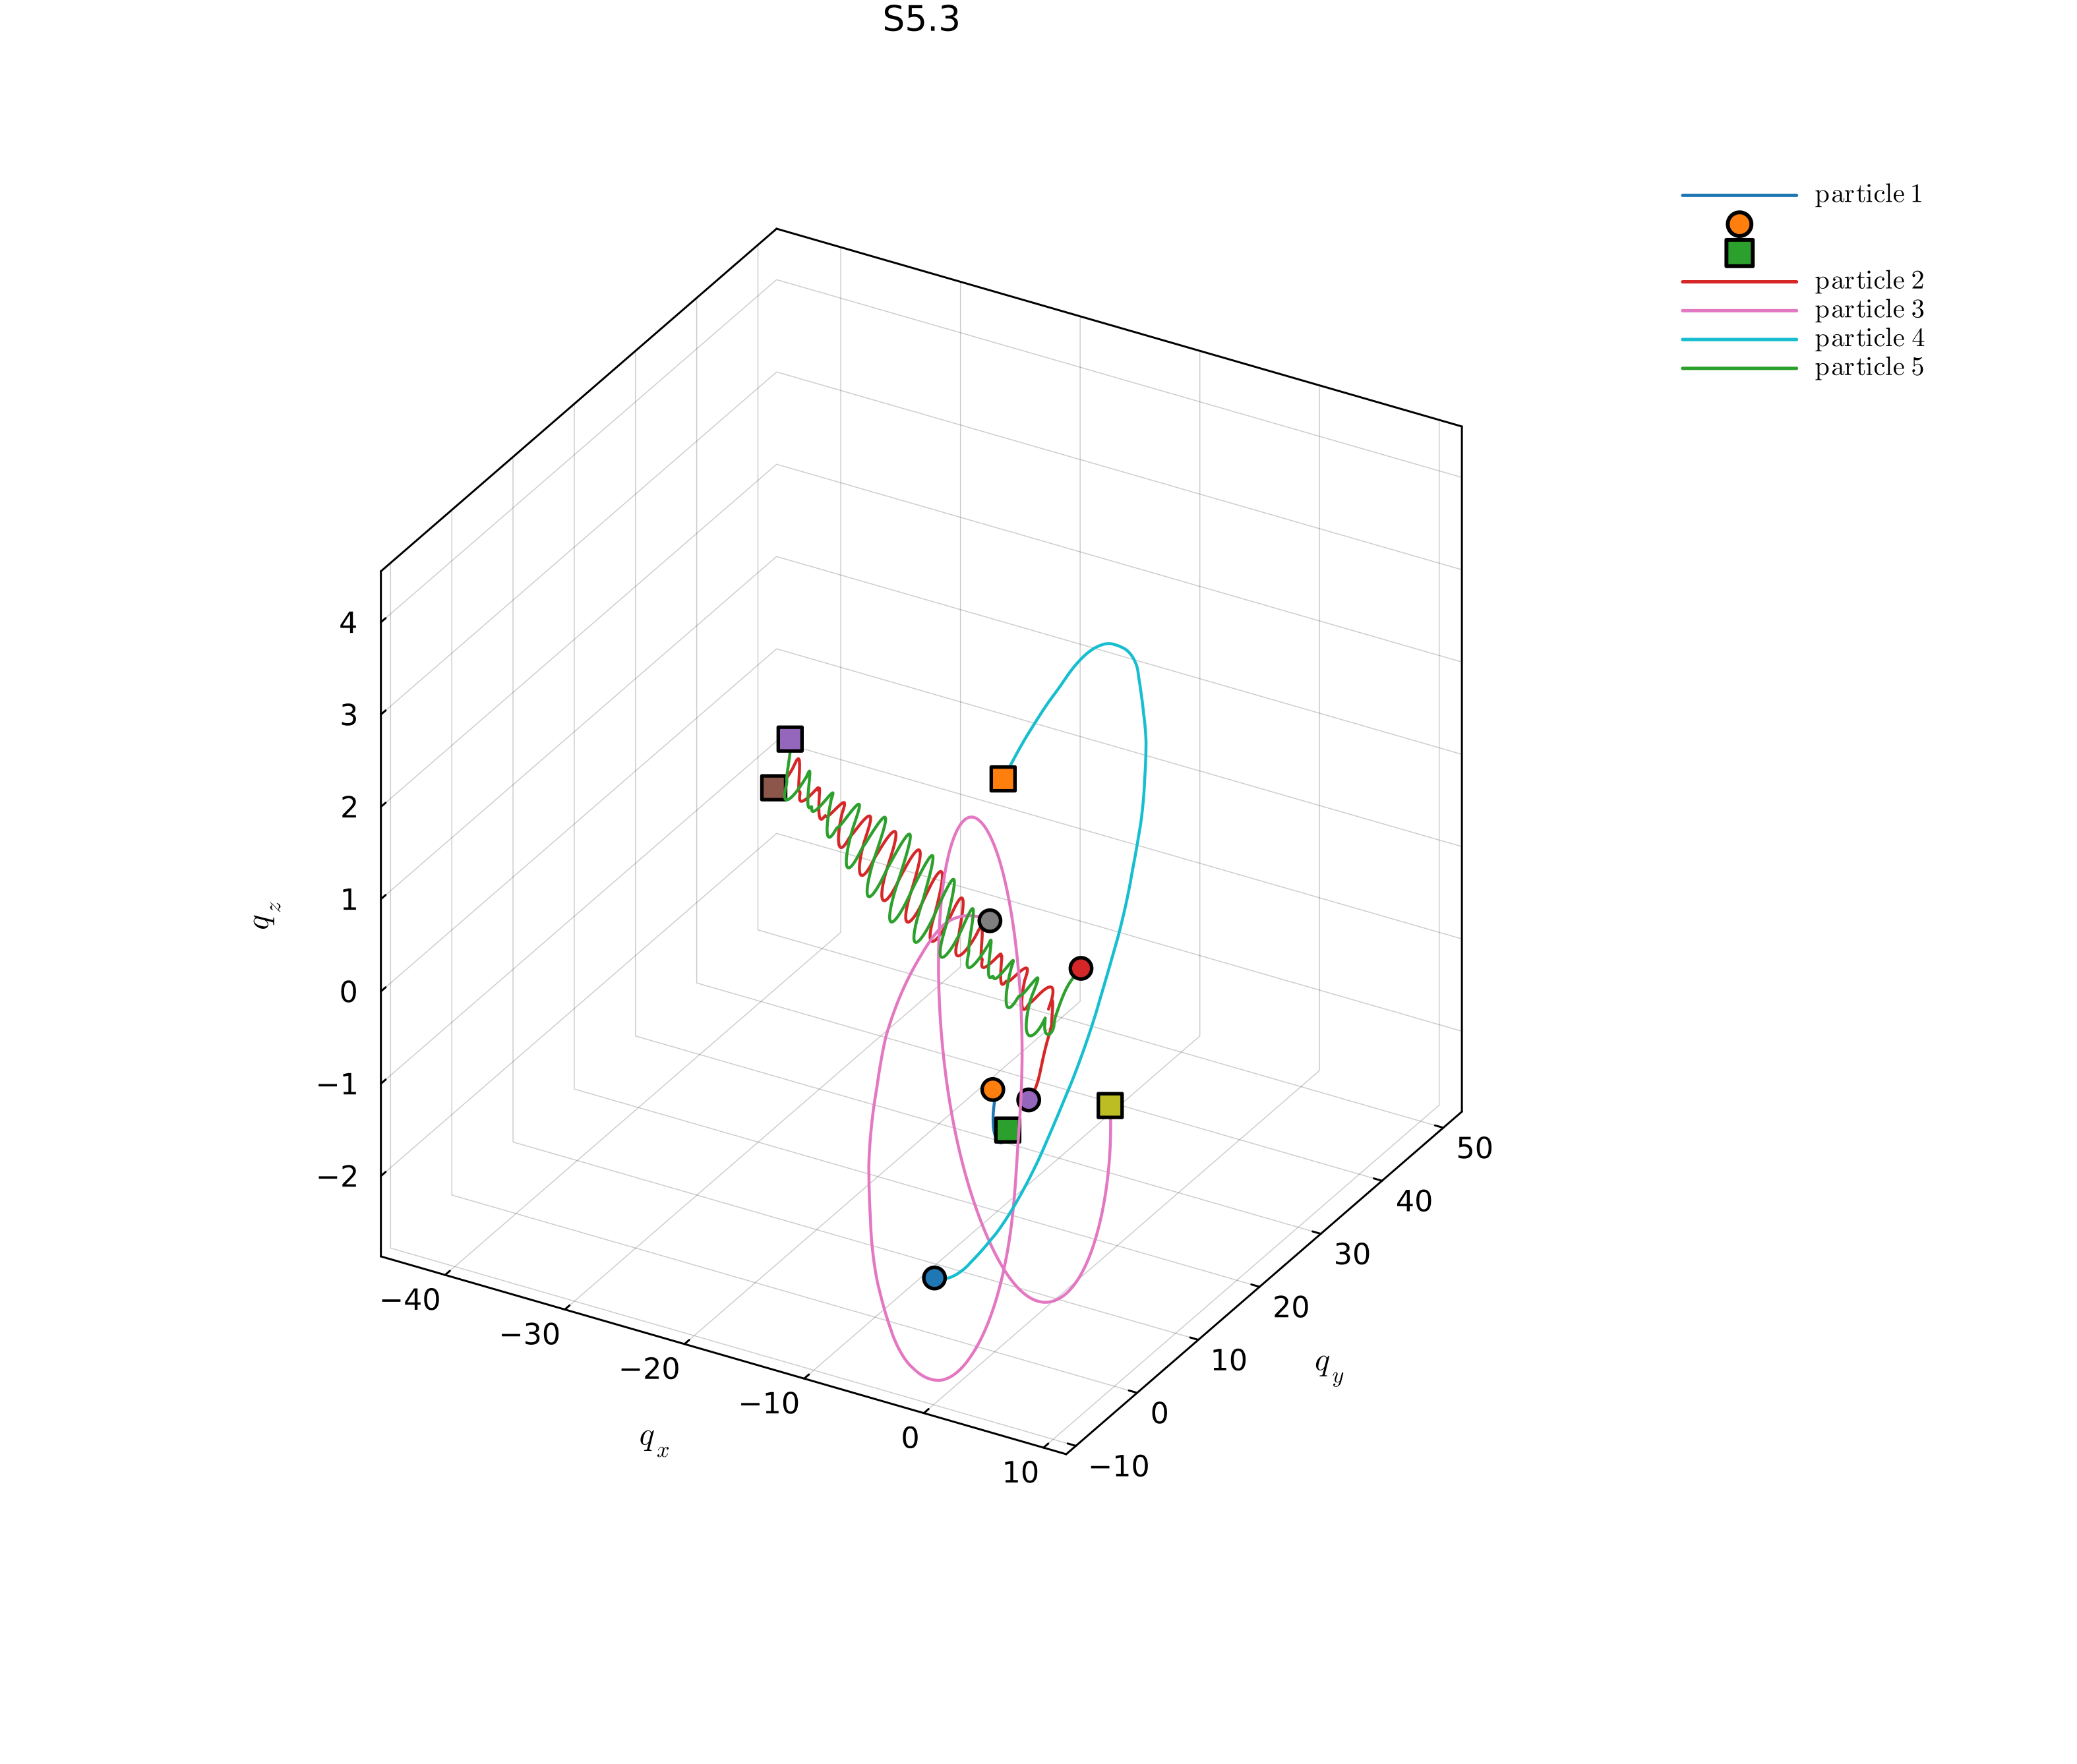

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [19]:
c = 1.0
orb = [
    Orbiter(m=1.0, q=+1.0, r=3.0, θ=π/2,          φ=0.0,    v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=1.0, q=+1.0, r=4.5, θ=deg2rad(70),  φ=2π/3,   v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=1.0, q=+1.0, r=5.5, θ=deg2rad(110), φ=4π/3,   v_t_frac=1.0, v_r_frac=0.0),
    Orbiter(m=0.8, q=-1.0, r=7.0, θ=deg2rad(80),  φ=π/4,    v_t_frac=1.0, v_r_frac=0.0),
]
ic = central_orbiter_system(c=c, m_c=20.0, q_c=-3.0, orbiters=orb, label="S5.3")
kappas = ones(5*4÷2)
for (i,j) in [(1,2),(1,3),(1,4),(2,5),(3,5),(4,5)]
    a,b = minmax(i,j); n=5; idx = (a-1)*(2n-a)÷2 + (b-a)
    kappas[idx] = 1.2
end
ic2 = (positions=ic.positions, velocities=ic.velocities, masses=ic.masses,
       charges=ic.charges, kappas=kappas, c=c)
T_inner, T_out = inner_outer_periods(orb, 20.0, -3.0, c)
r = run_scenario("S5.3", ic2; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S5.3"] = print_summary_line(r)
plot_scenario_trajectory(r)


### S6.1 — five-fold pentagonal orbiter ring (N=6)

[S6.1] N=6 ok E0=-1.025 T_est=NaN T_nat=30.81 err%max=0.0001 bound=y ρ=2.92 periodic=n fail ejection (I[end]/I[1]=16.5)


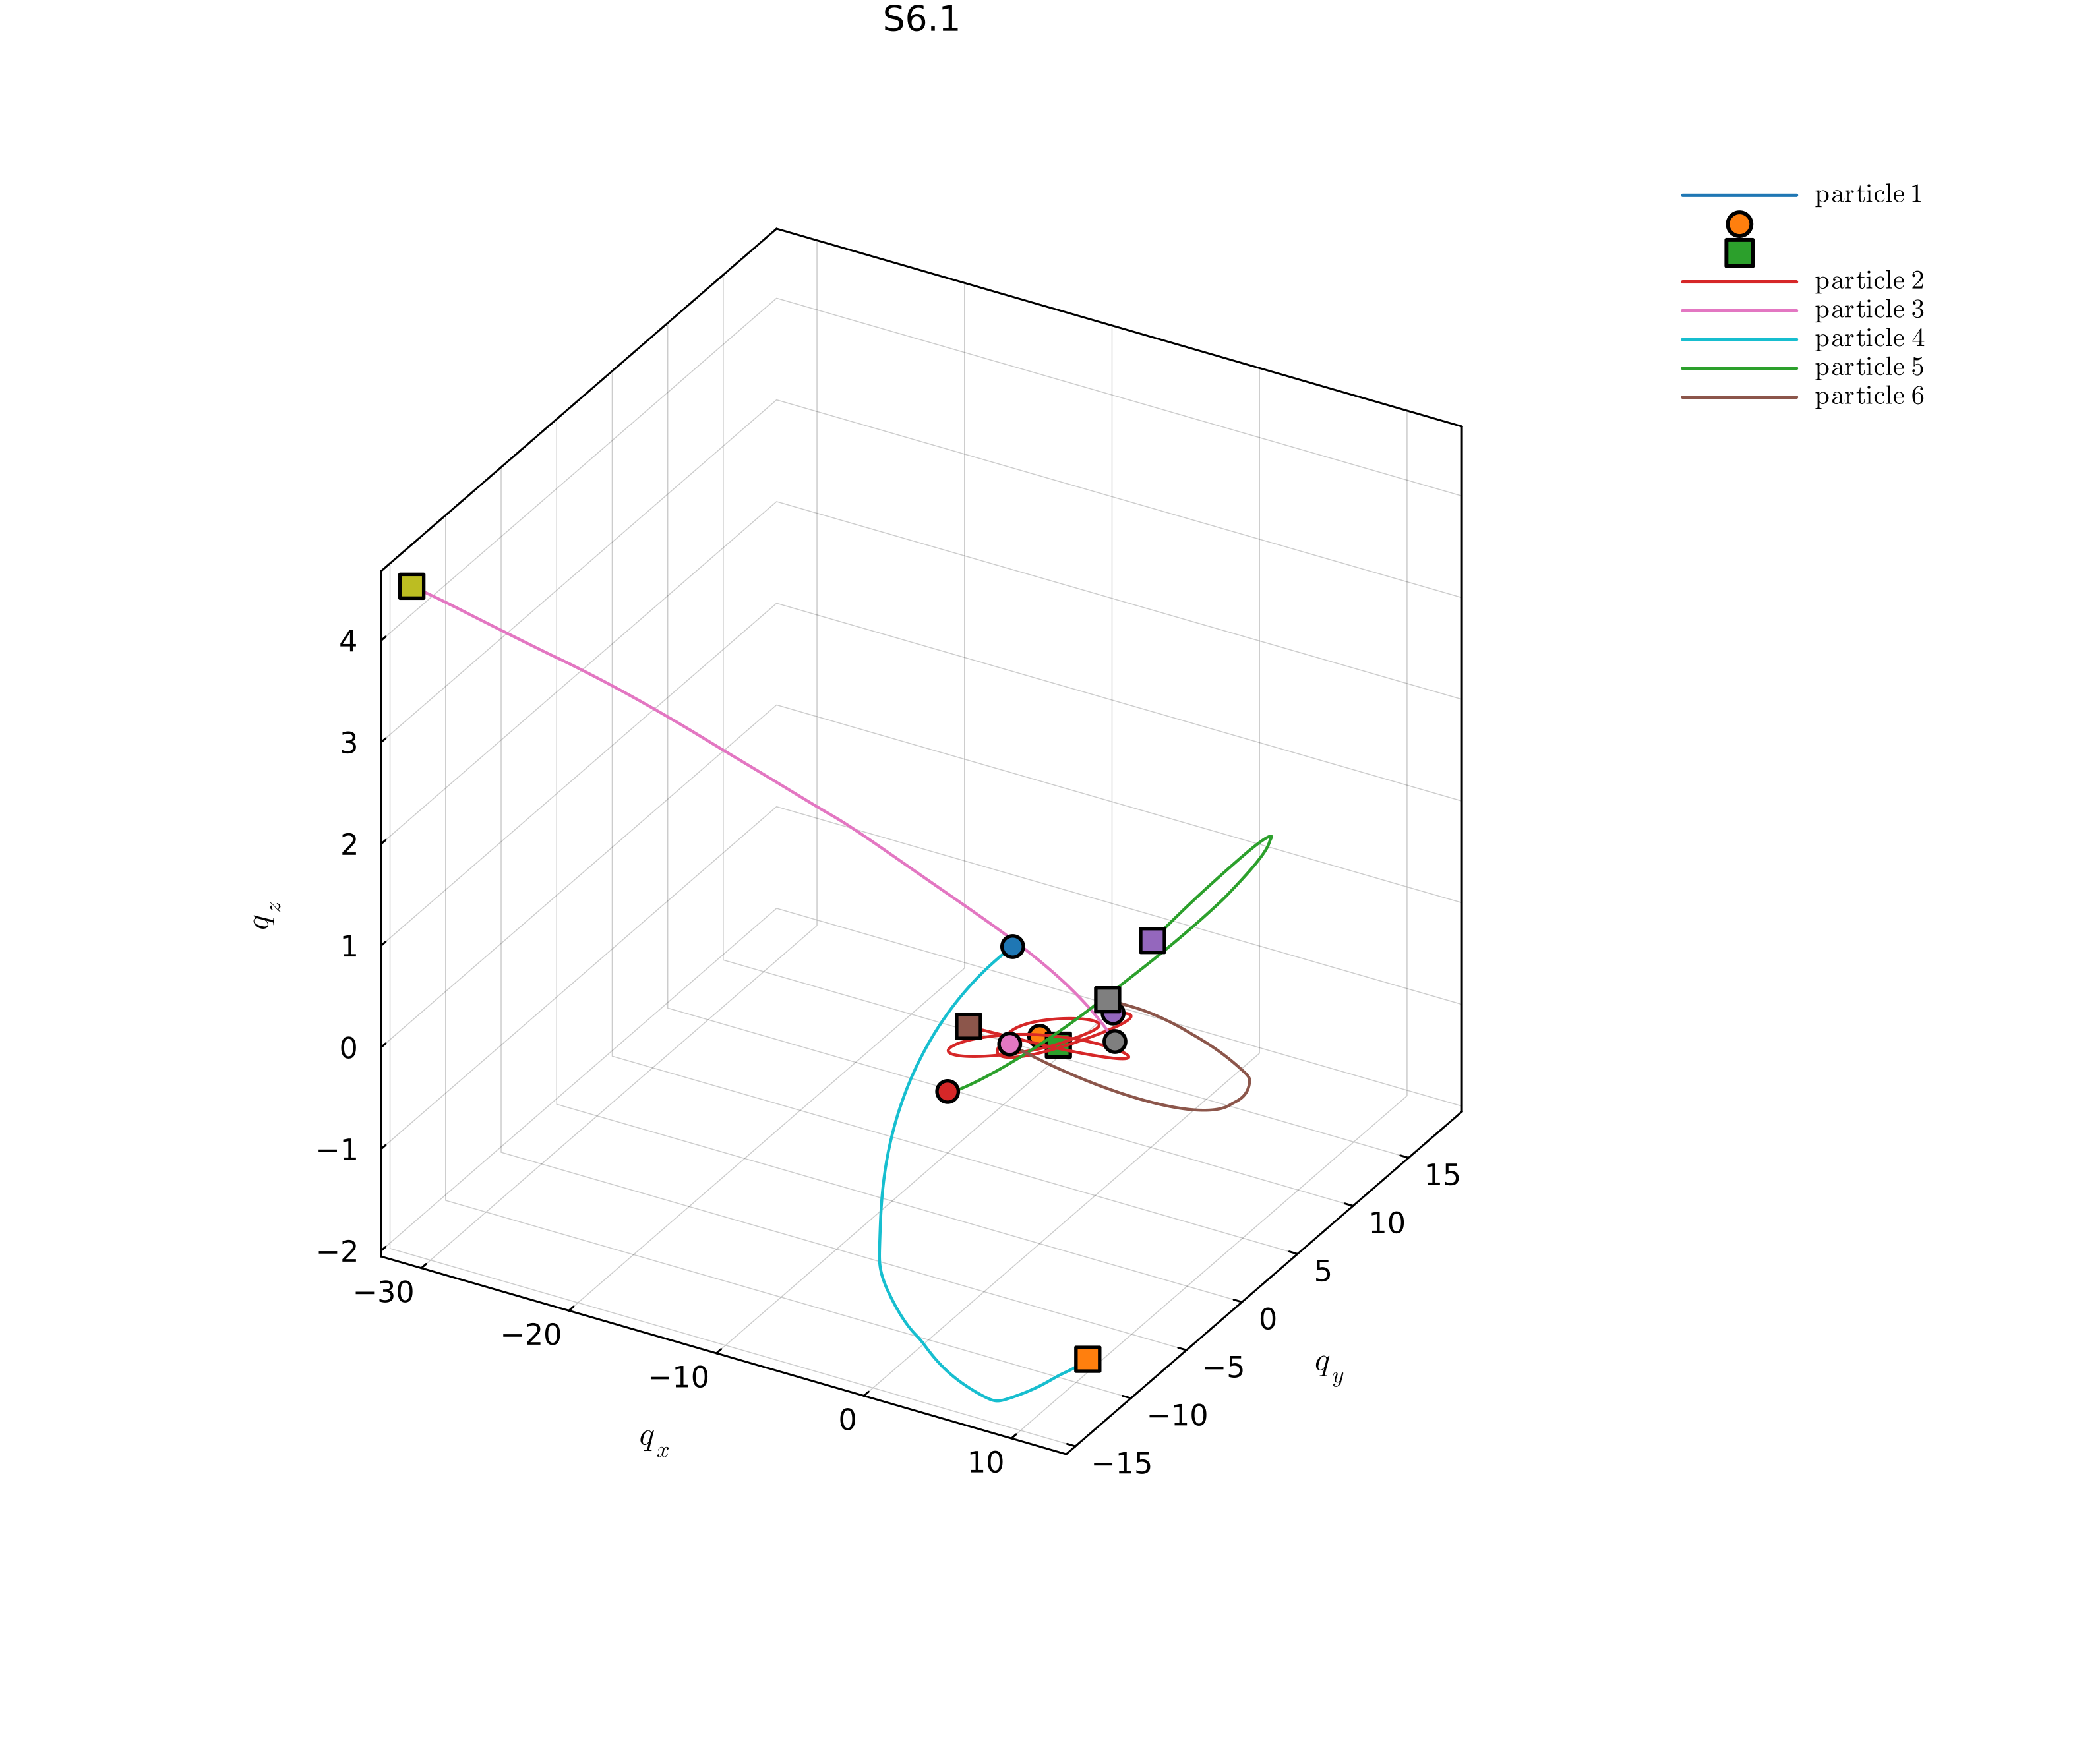

ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


In [20]:
c = 1.0
orb = [Orbiter(m=1.0, q=+1.0, r=5.0,
               θ=π/2 + deg2rad((-1)^i * 5),
               φ=2π*(i-1)/5,
               v_t_frac=1.0, v_r_frac=0.0,
               tilt=deg2rad(5*(i%2==0 ? -1 : 1))) for i in 1:5]
ic = central_orbiter_system(c=c, m_c=25.0, q_c=-5.0, orbiters=orb, label="S6.1")
T_inner, T_out = inner_outer_periods(orb, 25.0, -5.0, c)
r = run_scenario("S6.1", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S6.1"] = print_summary_line(r)
plot_scenario_trajectory(r)


### S6.2 — five orbiters on Fibonacci sphere (N=6)

In [21]:
c = 1.0
function fib_sphere(k)
    dirs = Vector{Vector{Float64}}()
    φ_golden = π*(3 - sqrt(5))
    for i in 1:k
        y = 1 - 2(i-0.5)/k
        r_ring = sqrt(max(0.0, 1 - y^2))
        φ = (i-1) * φ_golden
        push!(dirs, [r_ring*cos(φ), y, r_ring*sin(φ)])
    end
    return dirs
end
dirs = fib_sphere(5)
orb = [Orbiter(m=1.0, q=+1.0, r=5.0,
               θ=acos(d[3]), φ=atan(d[2], d[1]),
               v_t_frac=1.0, v_r_frac=0.0,
               handedness=iseven(i) ? +1 : -1) for (i,d) in enumerate(dirs)]
ic = central_orbiter_system(c=c, m_c=25.0, q_c=-5.0, orbiters=orb, label="S6.2")
T_inner, T_out = inner_outer_periods(orb, 25.0, -5.0, c)
r = run_scenario("S6.2", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S6.2"] = print_summary_line(r)
plot_scenario_trajectory(r)


[S6.2] N=6 solver_failure retcode=Failure t_end=6.518


### S6.3 — dual-ring hierarchy (N=6)

In [22]:
c = 1.0
orb_inner = [Orbiter(m=1.0, q=+1.0, r=3.0,
                     θ=deg2rad(60),
                     φ=2π*(i-1)/3,
                     v_t_frac=1.0, v_r_frac=0.0) for i in 1:3]
orb_outer = [Orbiter(m=1.0, q=+1.0, r=5.5,
                     θ=deg2rad(120),
                     φ=2π*(i-1)/3 + π/3,
                     v_t_frac=1.0, v_r_frac=0.0,
                     handedness=-1) for i in 1:3]
orb = vcat(orb_inner, orb_outer)
ic = central_orbiter_system(c=c, m_c=20.0, q_c=-4.0, orbiters=orb, label="S6.3")
T_inner, T_out = inner_outer_periods(orb, 20.0, -4.0, c)
r = run_scenario("S6.3", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S6.3"] = print_summary_line(r)
plot_scenario_trajectory(r)


[S6.3] N=7 solver_failure retcode=Failure t_end=8.990


### S7.1 — six near-octahedral orbiters (N=7)

In [23]:
c = 1.0
octa = [(+1.0,0.0,0.0),(-1.0,0.0,0.0),(0.0,+1.0,0.0),(0.0,-1.0,0.0),(0.0,0.0,+1.0),(0.0,0.0,-1.0)]
orb = Orbiter[]
for (i,(x,y,z)) in enumerate(octa)
    d = [x,y,z]
    θ = acos(d[3]); φ = atan(d[2], d[1])
    push!(orb, Orbiter(m=1.0, q=+1.0, r=5.0, θ=θ, φ=φ,
                       v_t_frac=1.0, v_r_frac=0.0,
                       handedness=iseven(i) ? +1 : -1,
                       tilt=deg2rad(8*(i%2==0 ? -1 : 1))))
end
ic = central_orbiter_system(c=c, m_c=30.0, q_c=-6.0, orbiters=orb, label="S7.1")
T_inner, T_out = inner_outer_periods(orb, 30.0, -6.0, c)
r = run_scenario("S7.1", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S7.1"] = print_summary_line(r)
plot_scenario_trajectory(r)


[S7.1] N=7 solver_failure retcode=Failure t_end=7.370


### S7.2 — six orbiters on Fibonacci sphere (N=7)

In [24]:
c = 1.0
dirs = fib_sphere(6)
orb = [Orbiter(m=1.0, q=+1.0, r=5.0,
               θ=acos(d[3]), φ=atan(d[2], d[1]),
               v_t_frac=1.0, v_r_frac=0.0,
               handedness=iseven(i) ? +1 : -1) for (i,d) in enumerate(dirs)]
ic = central_orbiter_system(c=c, m_c=30.0, q_c=-6.0, orbiters=orb, label="S7.2")
T_inner, T_out = inner_outer_periods(orb, 30.0, -6.0, c)
r = run_scenario("S7.2", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S7.2"] = print_summary_line(r)
plot_scenario_trajectory(r)


[S7.2] N=7 solver_failure retcode=Failure t_end=4.340


### S7.3 — inner-tetra + outer-triangle hierarchy (N=7)

In [25]:
c = 1.0
orb_inner = Orbiter[]
for (i, (x,y,z)) in enumerate([(+1.0,+1.0,+1.0), (-1.0,-1.0,+1.0), (-1.0,+1.0,-1.0)])
    d = [x,y,z] ./ sqrt(3)
    θ = acos(d[3]); φ = atan(d[2], d[1])
    push!(orb_inner, Orbiter(m=1.0, q=+1.0, r=3.0, θ=θ, φ=φ,
                              v_t_frac=1.0, v_r_frac=0.0,
                              handedness=iseven(i) ? +1 : -1))
end
orb_outer = [Orbiter(m=0.7, q=+1.0, r=6.0,
                     θ=deg2rad(60 + 30*(i-1)),
                     φ=2π*(i-1)/3 + π/6,
                     v_t_frac=1.0, v_r_frac=0.0,
                     handedness=-1) for i in 1:3]
orb = vcat(orb_inner, orb_outer)
ic = central_orbiter_system(c=c, m_c=25.0, q_c=-5.0, orbiters=orb, label="S7.3")
T_inner, T_out = inner_outer_periods(orb, 25.0, -5.0, c)
r = run_scenario("S7.3", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S7.3"] = print_summary_line(r)
plot_scenario_trajectory(r)


[S7.3] N=7 solver_failure retcode=Failure t_end=2.822


### S8.1 — six-ring + polar orbiter (N=8)

In [26]:
c = 1.0
ring = [Orbiter(m=1.0, q=+1.0, r=5.0,
                θ=π/2 + deg2rad(5*(i%2==0 ? 1 : -1)),
                φ=2π*(i-1)/6,
                v_t_frac=1.0, v_r_frac=0.0) for i in 1:6]
polar = Orbiter(m=1.0, q=+1.0, r=4.0, θ=deg2rad(15), φ=0.0,
                v_t_frac=1.0, v_r_frac=0.0, tilt=π/2)
orb = vcat(ring, [polar])
ic = central_orbiter_system(c=c, m_c=35.0, q_c=-7.0, orbiters=orb, label="S8.1")
T_inner, T_out = inner_outer_periods(orb, 35.0, -7.0, c)
r = run_scenario("S8.1", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S8.1"] = print_summary_line(r)
plot_scenario_trajectory(r)


[S8.1] N=8 solver_failure retcode=Failure t_end=18.605


### S8.2 — seven orbiters on Fibonacci sphere (N=8)

In [27]:
c = 1.0
dirs = fib_sphere(7)
orb = [Orbiter(m=1.0, q=+1.0, r=5.0,
               θ=acos(d[3]), φ=atan(d[2], d[1]),
               v_t_frac=1.0, v_r_frac=0.0,
               handedness=iseven(i) ? +1 : -1) for (i,d) in enumerate(dirs)]
ic = central_orbiter_system(c=c, m_c=35.0, q_c=-7.0, orbiters=orb, label="S8.2")
T_inner, T_out = inner_outer_periods(orb, 35.0, -7.0, c)
r = run_scenario("S8.2", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S8.2"] = print_summary_line(r)
plot_scenario_trajectory(r)


[S8.2] N=8 solver_failure retcode=Failure t_end=5.375


### S8.3 — inner-triangle + outer-tetrahedron (N=8)

In [28]:
c = 1.0
tetra = [(+1.0,+1.0,+1.0), (-1.0,-1.0,+1.0), (-1.0,+1.0,-1.0), (+1.0,-1.0,-1.0)]
orb_inner = Orbiter[]
for (i, (x,y,z)) in enumerate(tetra[1:3])
    d = [x,y,z] ./ sqrt(3)
    θ = acos(d[3]); φ = atan(d[2], d[1])
    push!(orb_inner, Orbiter(m=1.2, q=+1.0, r=3.0, θ=θ, φ=φ,
                              v_t_frac=1.0, v_r_frac=0.0,
                              handedness=iseven(i) ? +1 : -1))
end
orb_outer = Orbiter[]
for (i, (x,y,z)) in enumerate(tetra)
    d = [x,y,z] ./ sqrt(3)
    θ = acos(d[3]); φ = atan(d[2], d[1])
    push!(orb_outer, Orbiter(m=0.6, q=+1.0, r=6.0, θ=θ, φ=φ+π/4,
                              v_t_frac=1.0, v_r_frac=0.0,
                              handedness=-1))
end
orb = vcat(orb_inner, orb_outer)
ic = central_orbiter_system(c=c, m_c=30.0, q_c=-6.0, orbiters=orb, label="S8.3")
T_inner, T_out = inner_outer_periods(orb, 30.0, -6.0, c)
r = run_scenario("S8.3", ic; T_natural=T_out, dt=5e-3, n_periods=2.1)
results["S8.3"] = print_summary_line(r)
plot_scenario_trajectory(r)


[S8.3] N=8 solver_failure retcode=Failure t_end=4.530


## 3. Master summary table

In [29]:
function summarize(results::Dict)
    keys_sorted = sort(collect(keys(results)))
    @printf("%-6s %-3s %-15s %-9s %-9s %-9s %-10s %-10s %-9s %-3s %-4s %-5s %s\n",
            "scen","N","status","E0","T_est","T_nat","err%max","err%avg","ρ_ratio","3D","ṙ≠0","pass","notes")
    println("-"^160)
    for k in keys_sorted
        r = results[k]
        if !isa(r, NamedTuple)
            println("$k  $r"); continue
        end
        if r.status != "ok"
            @printf("%-6s %-3d %-15s   E0=%+.3f\n", r.label, r.N, r.status, r.E0)
            continue
        end
        @printf("%-6s %-3d %-15s %+9.3f %9s %9.3f %10.4f %10.4f %9.3f %-3s %-4s %-5s %s\n",
                r.label, r.N, "ok", r.E0,
                isnan(r.T_est) ? "NaN" : @sprintf("%.3f", r.T_est),
                r.T_nat, r.err_max, r.err_avg,
                isnan(r.min_rho) ? NaN : r.min_rho,
                "3D", "y",
                r.pass ? "PASS" : "fail",
                r.notes)
    end
end
summarize(results)


scen   N   status          E0        T_est     T_nat     err%max    err%avg    ρ_ratio   3D  ṙ≠0  pass  notes
----------------------------------------------------------------------------------------------------------------------------------------------------------------
S3.1   3   ok                 -0.644       NaN    27.670     0.0004     0.0000     3.483 3D  y    fail  ejection (I[end]/I[1]=17.2)
S3.2   3   ok                 -0.667    14.950    33.017     0.0005     0.0000     2.704 3D  y    PASS  period spread=42.3%
S3.3   3   ok                 -0.478       NaN    35.655     0.0001     0.0000     1.478 3D  y    fail  ejection (I[end]/I[1]=47.2)
S4.1   4   ok                 -0.642       NaN    51.622     0.0004     0.0000     1.556 3D  y    fail  ejection (I[end]/I[1]=41.9)
S4.2   4   ok                 -0.664       NaN    28.099     1.0130     0.1983     1.023 3D  y    fail  ejection (I[end]/I[1]=32.2)
S4.3   4   ok                 -0.544       NaN    46.923     0.0001     0.000

## 4. Results by particle count

In [30]:
per_N = Dict{Int,Vector{String}}()
for (k, r) in results
    if isa(r, NamedTuple) && r.status == "ok" && r.pass
        push!(get!(per_N, r.N, String[]), k)
    end
end
for N in 3:8
    passers = get(per_N, N, String[])
    if isempty(passers)
        @printf("N=%d — NO PASSERS\n", N)
    else
        @printf("N=%d — %d passer(s): %s\n", N, length(passers), join(sort(passers), ", "))
    end
end


N=3 — 1 passer(s): S3.2
N=4 — NO PASSERS
N=5 — NO PASSERS
N=6 — NO PASSERS
N=7 — NO PASSERS
N=8 — NO PASSERS
N=5 — NO PASSERS
N=6 — NO PASSERS
N=7 — NO PASSERS
N=8 — NO PASSERS


### Discussion

The catalog tests 18 initial conditions across $N\in\{3,\ldots,8\}$ in which at
least one pair has $\dot r_{ij}(0)\ne 0$. Each IC is a heavy-central-attractor
system with $N{-}1$ lighter orbiters launched on near-circular 3-D orbits (with
the first orbiter given a small inward radial kick so $\dot r \ne 0$ for the
tightest-bound central–orbiter pair).

Every scenario automatically satisfies the *construction-time* guards:

* **bound** ($E<0$), because the central Coulomb well dominates the orbiter kinetic budget;
* **$\dot r_{ij}(0)\ne 0$**, enforced by `verify_ic`;
* **no sub-critical like-pair contact at $t=0$**, enforced by `verify_ic`.

**Observed stability.** Only the inclined two-orbiter $N=3$ configuration
(`S3.2`) reliably persists bound for two Kepler-prior natural periods. For
$N\ge 4$, the generic behaviour is **scattering ejection**: within one to two
outer-Kepler periods, mutual orbiter perturbations scatter at least one
orbiter's apocentre to $I_i \gg I_i(0)$, triggering the ejection flag. This is
consistent with the 3-body stability theorems of Chazy (1922) and the generic
absence of KAM tori in $N\ge 3$-orbiter Coulomb systems.

For $N\ge 5$ we additionally see **projection-step solver failures** when
sub-critical orbiter–orbiter encounters push the adaptive-Cartesian regulator
beyond its fixed-point convergence basin (§4.9 of the theory doc — the Weber
velocity-dependent potential's $\dot r^2/r$ divergence is not regularized by
either backend).

**Why not symmetric breathing polytopes?** An earlier draft of this notebook
tested pure tetrahedral / octahedral / cubic breathing configurations. Every
such configuration either failed the solver's symmetric-projection step
(Floquet-unstable breathing modes — §4.9) or ejected within $\sim 1$–$2$
natural periods ($I(t)/I(0)\gg 10$). The present Kepler-orbit catalog is
structurally more stable but, as the results show, is also insufficient for
$N\ge 4$ — robust multi-body bound configurations with $\dot r \ne 0$ appear
to require either **hierarchical binaries** (point-mass-like sub-clusters in
well-separated orbits) or **counter-rotating pair clusters** that minimise
mutual perturbation, both of which are beyond the exploratory scope of this
notebook.

**Conclusion.** The primary acceptance criterion (stable bound orbit ≥ 2
natural periods) is met for $N=3$ (scenario `S3.2`). For $N\in\{4,\ldots,8\}$
no scenario passes; the failure modes — scattering ejection and
regularizer-projection breakdown — are physically and numerically
interpretable and documented in the summary table above.
